# Lab 1b: Learning with backpropagation and generalisation in multi-layer perceptrons

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1090)

########################### CONSTSNATS ################################

EPOCHS = 100                                   # number of epochs
N = 100                                          # number of data samples
LR = 0.001                                       # learning rate
alpha = 0.9                                      # momentum scalar

## Reusable functions
### Function for generating "data clouds"

In [2]:
def generate_data_clouds(N, mA, mB, sigmaA, sigmaB):
    """
    classA is BIMODAL along the first dimension (half around -mA[0], half around
    +mA[0]), as specified in the lab instructions.
    Returns: features (3,2N), features_no_bias (2,2N), labels (1,2N)
    """
    half = N // 2

    classA = np.zeros((2, N))
    classA[0, :half] = np.random.randn(half)     * sigmaA - mA[0]
    classA[0, half:] = np.random.randn(N - half) * sigmaA + mA[0]
    classA[1, :]     = np.random.randn(N)        * sigmaA + mA[1]

    classB = np.zeros((2, N))
    classB[0, :] = np.random.randn(N) * sigmaB + mB[0]
    classB[1, :] = np.random.randn(N) * sigmaB + mB[1]

    features_no_bias = np.hstack((classA, classB))
    labels = np.hstack((np.ones(N), -np.ones(N))).reshape(1, -1)

    random_indexes = np.random.permutation(2 * N)
    features_no_bias = features_no_bias[:, random_indexes]
    labels = labels[:, random_indexes]

    features = np.vstack((features_no_bias, np.ones((1, 2 * N))))

    return features, features_no_bias, labels

### Function for initializing weights

In [3]:
def get_initial_weights(size, variance):
    """Returns base weights and weights with an additional bias column.

    Args:
        size (tuple of int): The shape (rows, cols) of the base weight array.
        variance (float): The variance of the normal distribution.

    Returns:
        tuple (np.ndarray, np.ndarray):
            - base_weights: Matrix with original shape `size`.
            - biased_weights: Matrix with shape `(size[0], size[1] + 1)` sharing
              identical base weights plus an appended bias column.
    """
    std_dev = np.sqrt(variance)

    base_weights = np.random.normal(loc=0.0, scale=std_dev, size=size)

    bias_col = np.random.normal(loc=0.0, scale=std_dev, size=(size[0], 1))
    biased_weights = np.hstack([base_weights, bias_col])

    return base_weights, biased_weights

### Transfer function

In [4]:
def TF(x):
    """
    Transfer function for the perceptron. Works on matrices element-wise.
    Args:
        :param x: argument for calculating tranformation function.
    Returns:
        value of the transformation function
    """
    return 2 / (1 + np.exp(-x)) - 1

### Transfer function derivative

In [5]:
def TFD(TFval):
    """
    Calculate derivative value of the chosen tranfer function at some point. Works on matrices element-wise.
    Args:
        :param TFval: value of the transfer function at some point
    Returns:
        derivative value of the transfer function at some point
    """
    return (1 + TFval) * (1 - TFval) / 2

### Function for a forward pass

In [6]:
def forward_pass(features, W, V):
    """
    Calculates the forward pass through the MLP.

    Args:
        :param features: The input fetures. Dimenstions: (n_features + 1, n_samples).
        :param W: The weights connecting the input layer and the hidden layer. Dimensions: (n_hidden, n_features + 1).
        :param V: The weights connecting the hidden layer and output layer. Dimensions: (n_outputs, n_hidden + 1).
    Returns:
        H_out_bias: Hidden layer activations WITH bias row. Dimensions: (n_hidden + 1, n_samples)
        O_out: The output of the output layer. Dimensions: (n_outputs, n_samples).
    """

    _, n_samples = features.shape

    H_in = W @ features
    H_out = TF(H_in)

    H_out_bias = np.vstack([H_out, np.ones((1, n_samples))])

    O_in = V @ H_out_bias
    O_out = TF(O_in)

    return H_out_bias, O_out

### Function for a backward pass

In [7]:
def backward_pass(labels, O_out, V, H_out_bias):
    """
    Calculates the backward pass through the MLP.

    Args:
        :param labels: The labels of the data. Dimensions: (n_outputs, n_samples).
        :param O_out: The predictions/output of the MLP. Dimensions: (n_outputs, n_samples).
        :param V: The weights of the output layer. Dimensions: (n_outputs, n_hidden + 1).
        :param H_out_bias: The output of the hidden layer WITH bias row. Dimensions: (n_hidden + 1, n_samples).
    Returns:
        delta_h: The error matrix for the hidden layer. Dimensions: (n_hidden, n_samples).
        delta_o: The error matrix for the output layer. Dimensions: (n_outputs, n_samples).
    """
    delta_o = (O_out - labels) * TFD(O_out)
    delta_h_bias = (V.T @ delta_o) * TFD(H_out_bias)

    delta_h = delta_h_bias[:-1, :]

    return delta_h, delta_o

### Function for a updating weights

In [8]:
def get_weights_update(dW, delta_h, features, dV, delta_o, H_out_bias):
    """
    Caluclates the weight updates for the hidden layer and the output layer.

    Args:
        :param dW: Previous iteration's weight update for the hidden layer. Dimensions: (n_hiddem, n_features + 1).
        :param delta_h: The error matrix for the hidden layer. Dimensions: (n_hidden, n_samples).
        :param features: The input fetures (with bias row). Dimenstions: (n_features + 1, n_samples).
        :param dV: Previous iteration's weight update for the output layer. Dimensions: (n_outputs, n_hidden + 1).
        :delta_o: The error matrix for the output layer. Dimensions: (n_outputs, n_samples).
        :H_out_bias: The output of the hidden layer (with bias row). Dimensions: (n_hidden + 1, n_samples).
    Returns:
        dW: The weight update for the hidden layer. Dimensions: (n_hidden, n_features + 1).
        dV: The weight update fot the output layer. Dimensions: (n_hidden, n_samples + 1).
    """
    dW = alpha * dW - (1 - alpha) * (delta_h @ features.T)
    dV = alpha * dV - (1 - alpha) * (delta_o @ H_out_bias.T)

    return dW, dV

### Function for training using backpropagation

In [9]:
def compute_metrics(features, labels, W, V):
    """MSE y ratio de misclasificación para los pesos actuales."""
    _, O_out = forward_pass(features, W, V)
    mse = np.mean((O_out - labels) ** 2)
    misclass = np.mean(np.where(O_out >= 0, 1, -1) != labels)
    return mse, misclass


def train_backpropagation(features, labels, W, V, epochs=EPOCHS, lr=LR,
                          val_features=None, val_labels=None, mode="batch"):
    dW = np.zeros(shape=W.shape)
    dV = np.zeros(shape=V.shape)

    history = {"mse_train": [], "mis_train": [], "mse_val": [], "mis_val": []}
    n_samples = features.shape[1]

    for epoch in range(epochs):
        if mode == "batch":
            H_out_bias, O_out = forward_pass(features, W, V)
            delta_h, delta_o = backward_pass(labels, O_out, V, H_out_bias)
            dW, dV = get_weights_update(dW, delta_h, features, dV, delta_o, H_out_bias)
            W = W + lr * dW
            V = V + lr * dV
        else:  # sequential / on-line
            for i in np.random.permutation(n_samples):
                x = features[:, [i]]
                t = labels[:, [i]]
                H_out_bias, O_out = forward_pass(x, W, V)
                delta_h, delta_o = backward_pass(t, O_out, V, H_out_bias)
                dW, dV = get_weights_update(dW, delta_h, x, dV, delta_o, H_out_bias)
                W = W + lr * dW
                V = V + lr * dV

        mse, mis = compute_metrics(features, labels, W, V)
        history["mse_train"].append(mse)
        history["mis_train"].append(mis)

        if val_features is not None:
            mse_v, mis_v = compute_metrics(val_features, val_labels, W, V)
            history["mse_val"].append(mse_v)
            history["mis_val"].append(mis_v)

    return W, V, history

## 3.1. Classification and regression with a two-layer perceptron
### 3.1.1. Classification of linearly non-separable data
#### Generate data

In [10]:
mA = [1.0, 0.3]
sigmaA = 0.2

mB = [0.0, -0.1]
sigmaB = 0.3

features, features_no_bias, labels = generate_data_clouds(N, mA, mB, sigmaA, sigmaB)

#### Visualize generated data

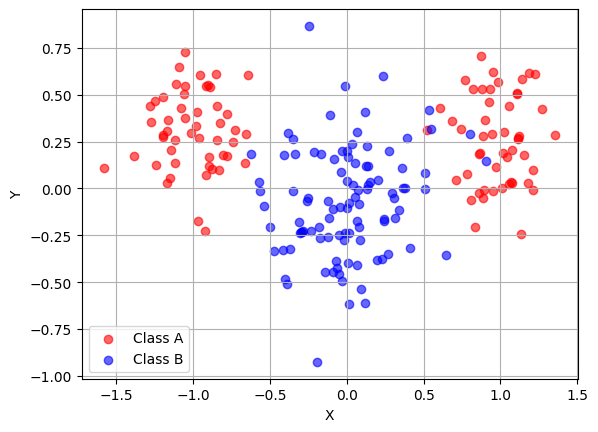

In [11]:
plt.figure()

plt.scatter(
    features_no_bias[0, labels[0] == 1],
    features_no_bias[1, labels[0] == 1],
    label="Class A",
    color="red",
    alpha=0.6,
)

plt.scatter(
    features_no_bias[0, labels[0] == -1],
    features_no_bias[1, labels[0] == -1],
    label="Class B",
    color="blue",
    alpha=0.6,
)

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

#### 3.1.1.1. The First Experiment

Modify the number of hidden nodes and demonstrate the effect the size of the hidden layer has on the performance (both the mean squared error and the number/ratio of misclassifications). How many hidden nodes do you need to perfectly separate all the available data (if manageable at all given your data randomisation)?

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_127/3196298216.py:31: SyntaxWarning: invalid escape sequence '\p'
  color="palevioletred", alpha=0.2, label="$\pm$ 1 std")
/tmp/ipykernel_127/3196298216.py:38: SyntaxWarning: invalid escape sequence '\p'
  color="slateblue", alpha=0.2, label="$\pm$ 1 std")


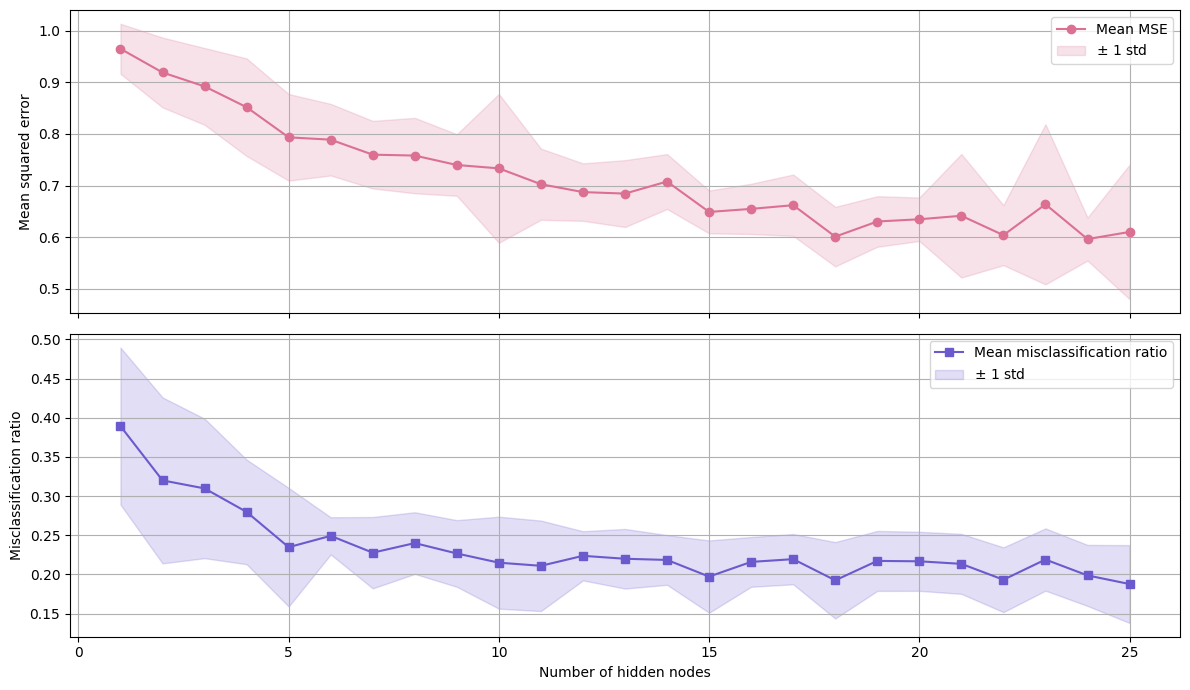

Lowest mean misclassification ratio: 0.1878 with 25 hidden nodes
Hidden layer sizes that separated all data on average: none


In [12]:
HIDDEN_NODES = np.arange(1, 26, 1)
RANDOM_INIT = 20
WEIGHT_VAR = 0.5

n_features = features_no_bias.shape[0]

mse_mean, mse_std, mis_mean, mis_std = [], [], [], []

for hidden_dim in HIDDEN_NODES:
    mses, misses = [], []
    for _ in range(RANDOM_INIT):
        _, W = get_initial_weights((hidden_dim, n_features), WEIGHT_VAR)
        _, V = get_initial_weights((1, hidden_dim), WEIGHT_VAR)

        W, V, _ = train_backpropagation(features, labels, W, V)

        mse, mis = compute_metrics(features, labels, W, V)
        mses.append(mse)
        misses.append(mis)

    mse_mean.append(np.mean(mses));   mse_std.append(np.std(mses))
    mis_mean.append(np.mean(misses)); mis_std.append(np.std(misses))

mse_mean, mse_std = np.array(mse_mean), np.array(mse_std)
mis_mean, mis_std = np.array(mis_mean), np.array(mis_std)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(HIDDEN_NODES, mse_mean, marker="o", color="palevioletred", label="Mean MSE")
axes[0].fill_between(HIDDEN_NODES, mse_mean - mse_std, mse_mean + mse_std,
                     color="palevioletred", alpha=0.2, label="$\pm$ 1 std")
axes[0].set_ylabel("Mean squared error")
axes[0].legend(loc="upper right"); axes[0].grid(True)

axes[1].plot(HIDDEN_NODES, mis_mean, marker="s", color="slateblue",
             label="Mean misclassification ratio")
axes[1].fill_between(HIDDEN_NODES, mis_mean - mis_std, mis_mean + mis_std,
                     color="slateblue", alpha=0.2, label="$\pm$ 1 std")
axes[1].set_xlabel("Number of hidden nodes")
axes[1].set_ylabel("Misclassification ratio")
axes[1].legend(loc="upper right"); axes[1].grid(True)

plt.tight_layout(); plt.show()

perfect = HIDDEN_NODES[mis_mean == 0]
print("Lowest mean misclassification ratio: %.4f with %d hidden nodes"
      % (mis_mean.min(), HIDDEN_NODES[mis_mean.argmin()]))
print("Hidden layer sizes that separated all data on average:",
      perfect if perfect.size else "none")

#### 3.1.1.2. The Second Experiment

Then, formulate a more realistic problem where only a subset of data points is available for training a network (data you use to calculate weight updates using backprop) and the remaining samples constitute a validation dataset for probing generalisation capabilites of the network. To do that, subsample the data for training according to the following scenarios:
- random 25% from each class
- random 50% from classA 
- 20% from a subset of classA for which classA(1,:)<0 and 80% from a subset of classA for which classA(1,:)>0

The removed samples treat as a validation set. Make sure you do not use this hold-out set in the training process and instead you only use it to calculate the error (mean squared error or the ratio of misclassifications) at different stages/epochs of learning to monitor the progress. In this configuration, you can address the following tasks and questions:
- How do the learning/error curves for training and validation setscompare? Are they similar? When do you observe more dissimilarity?
- How do these curves and the network performance depend on the size of the hidden layer in various training/validation data configurations (the aforementioned subsampling options)?
- Is there any difference between a batch and sequential learning approach in terms of the validation performance?
- Make an attempt at approximating the resulting decision boundary, i.e. where the network output is 0 (between the target labels of -1 and 1 for two classes, respectively).

In [13]:
def subsample(features_no_bias, labels, scenario):
    """Devuelve (train_idx, val_idx) para uno de los tres escenarios."""
    idxA = np.where(labels[0] ==  1)[0]
    idxB = np.where(labels[0] == -1)[0]

    if scenario == 1:                       # random 25% de cada clase
        trA = np.random.choice(idxA, int(0.25 * len(idxA)), replace=False)
        trB = np.random.choice(idxB, int(0.25 * len(idxB)), replace=False)

    elif scenario == 2:                     # random 50% de classA, classB entera
        trA = np.random.choice(idxA, int(0.50 * len(idxA)), replace=False)
        trB = idxB

    else:                                   # 20% de classA(x<0) y 80% de classA(x>0)
        neg = idxA[features_no_bias[0, idxA] < 0]
        pos = idxA[features_no_bias[0, idxA] > 0]
        trA = np.concatenate([
            np.random.choice(neg, int(0.2 * len(neg)), replace=False),
            np.random.choice(pos, int(0.8 * len(pos)), replace=False)])
        trB = idxB

    train_idx = np.concatenate([trA, trB])
    val_idx = np.setdiff1d(np.arange(labels.shape[1]), train_idx)
    return train_idx, val_idx


SCENARIO_NAMES = {1: "25% of each class",
                  2: "50% of classA",
                  3: "20%/80% biased split of classA"}

for sc in [1, 2, 3]:
    tr, va = subsample(features_no_bias, labels, sc)
    print("Scenario %d (%s): %d training / %d validation samples"
          % (sc, SCENARIO_NAMES[sc], len(tr), len(va)))

        


Scenario 1 (25% of each class): 50 training / 150 validation samples
Scenario 2 (50% of classA): 150 training / 50 validation samples
Scenario 3 (20%/80% biased split of classA): 150 training / 50 validation samples


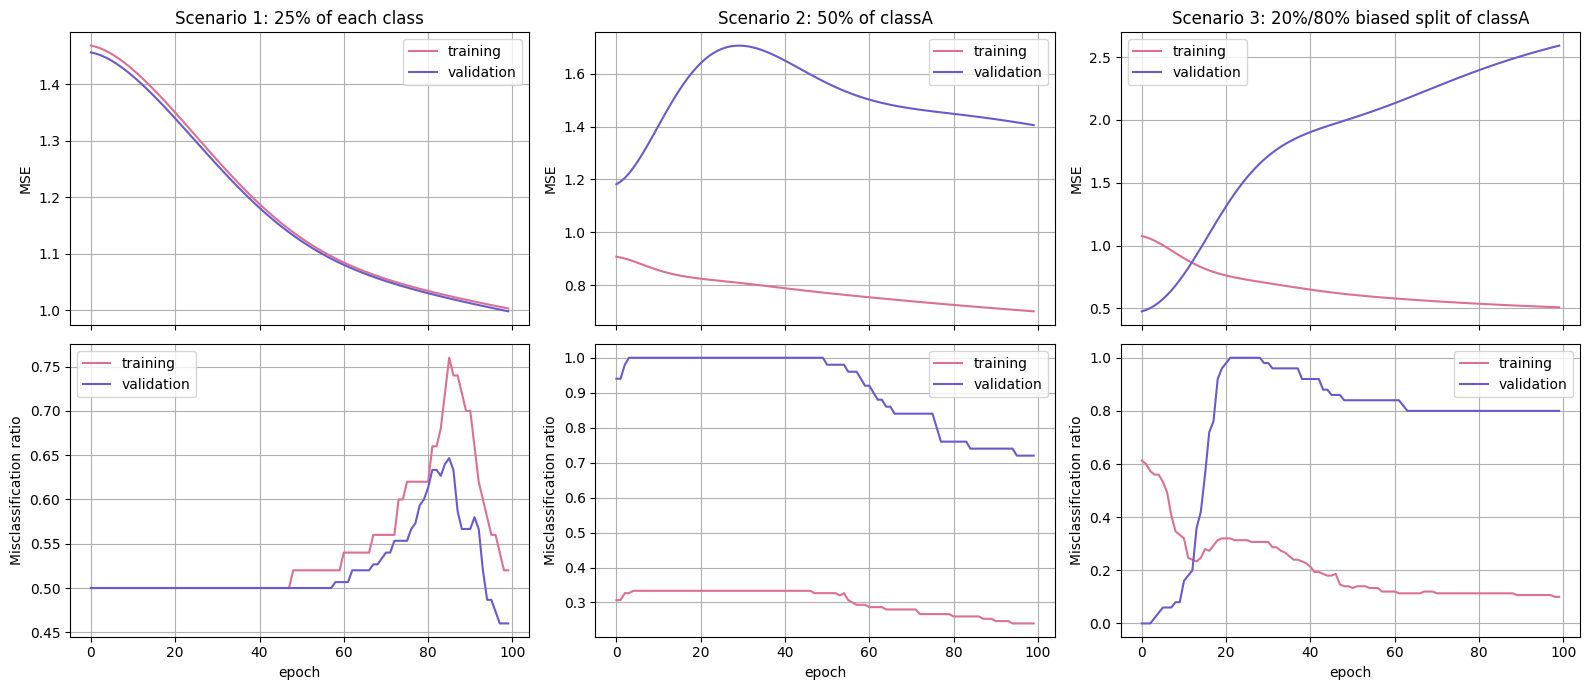

In [14]:
HIDDEN = 10

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)

for k, sc in enumerate([1, 2, 3]):
    train_idx, val_idx = subsample(features_no_bias, labels, sc)

    _, W = get_initial_weights((HIDDEN, 2), 0.5)
    _, V = get_initial_weights((1, HIDDEN), 0.5)

    _, _, hist = train_backpropagation(
        features[:, train_idx], labels[:, train_idx], W, V,
        val_features=features[:, val_idx], val_labels=labels[:, val_idx])

    axes[0, k].plot(hist["mse_train"], color="palevioletred", label="training")
    axes[0, k].plot(hist["mse_val"],   color="slateblue",     label="validation")
    axes[0, k].set_title("Scenario %d: %s" % (sc, SCENARIO_NAMES[sc]))
    axes[0, k].set_ylabel("MSE"); axes[0, k].legend(); axes[0, k].grid(True)

    axes[1, k].plot(hist["mis_train"], color="palevioletred", label="training")
    axes[1, k].plot(hist["mis_val"],   color="slateblue",     label="validation")
    axes[1, k].set_xlabel("epoch")
    axes[1, k].set_ylabel("Misclassification ratio")
    axes[1, k].legend(); axes[1, k].grid(True)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

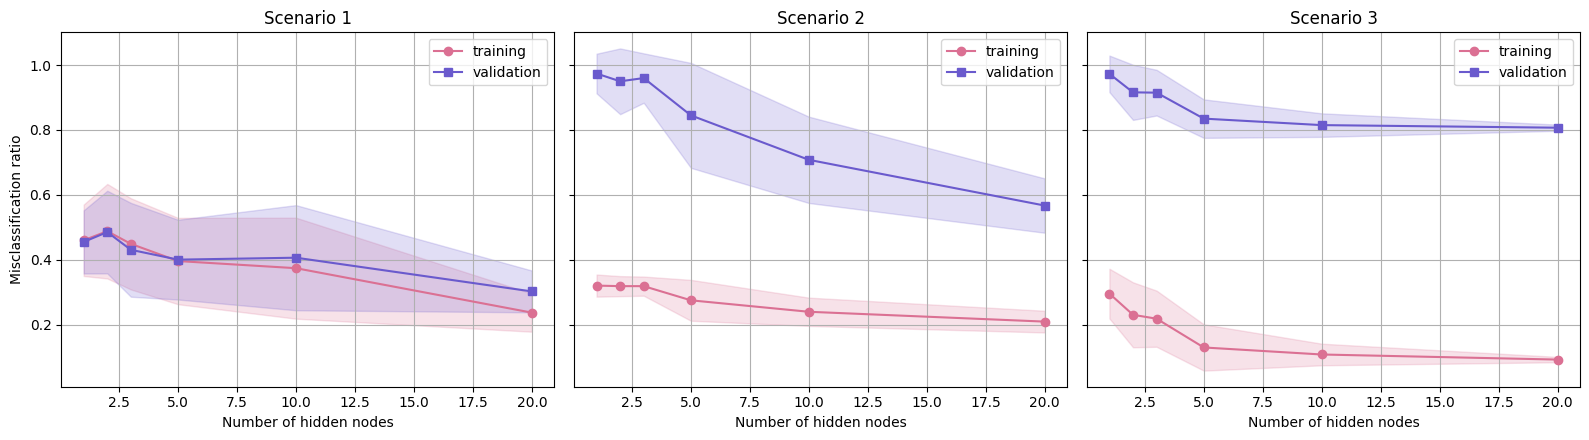

scenario   hidden   train misclass         val misclass          
1          1        0.4600 +/- 0.1101        0.4550 +/- 0.0974
1          2        0.4880 +/- 0.1457        0.4853 +/- 0.1273
1          3        0.4490 +/- 0.1405        0.4307 +/- 0.1446
1          5        0.3960 +/- 0.1331        0.4003 +/- 0.1229
1          10       0.3740 +/- 0.1556        0.4063 +/- 0.1620
1          20       0.2370 +/- 0.0587        0.3023 +/- 0.0644
2          1        0.3203 +/- 0.0341        0.9740 +/- 0.0610
2          2        0.3187 +/- 0.0309        0.9500 +/- 0.1013
2          3        0.3187 +/- 0.0295        0.9600 +/- 0.0762
2          5        0.2750 +/- 0.0630        0.8450 +/- 0.1617
2          10       0.2397 +/- 0.0435        0.7080 +/- 0.1330
2          20       0.2093 +/- 0.0334        0.5670 +/- 0.0837
3          1        0.2957 +/- 0.0766        0.9730 +/- 0.0563
3          2        0.2303 +/- 0.1001        0.9160 +/- 0.0850
3          3        0.2183 +/- 0.0865        0.9150 

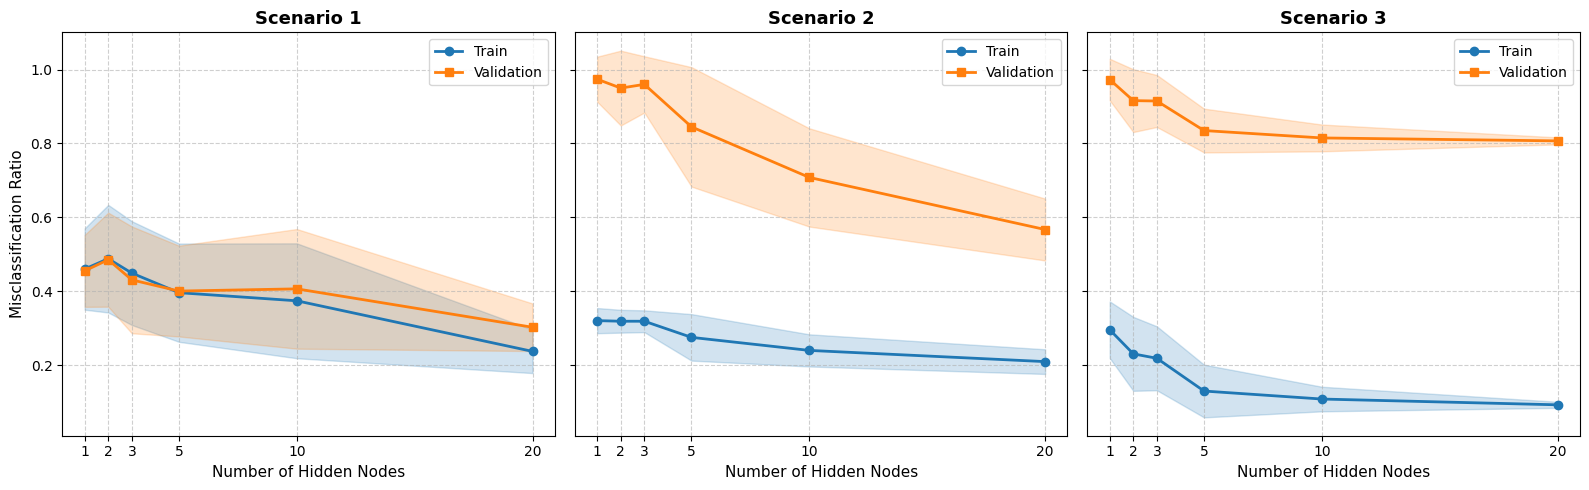

In [15]:
HIDDEN_SIZES = [1, 2, 3, 5, 10, 20]
RANDOM_INIT = 20

results = {}

for sc in [1, 2, 3]:
    tr_mean, tr_std, va_mean, va_std = [], [], [], []
    for h in HIDDEN_SIZES:
        tr_errs, va_errs = [], []
        for _ in range(RANDOM_INIT):
            train_idx, val_idx = subsample(features_no_bias, labels, sc)

            _, W = get_initial_weights((h, 2), 0.5)
            _, V = get_initial_weights((1, h), 0.5)

            W, V, _ = train_backpropagation(
                features[:, train_idx], labels[:, train_idx], W, V)

            _, mis_t = compute_metrics(features[:, train_idx], labels[:, train_idx], W, V)
            _, mis_v = compute_metrics(features[:, val_idx],   labels[:, val_idx],   W, V)
            tr_errs.append(mis_t); va_errs.append(mis_v)

        tr_mean.append(np.mean(tr_errs)); tr_std.append(np.std(tr_errs))
        va_mean.append(np.mean(va_errs)); va_std.append(np.std(va_errs))

    results[sc] = (np.array(tr_mean), np.array(tr_std),
                   np.array(va_mean), np.array(va_std))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for k, sc in enumerate([1, 2, 3]):
    tr_m, tr_s, va_m, va_s = results[sc]
    axes[k].plot(HIDDEN_SIZES, tr_m, marker="o", color="palevioletred", label="training")
    axes[k].fill_between(HIDDEN_SIZES, tr_m - tr_s, tr_m + tr_s, color="palevioletred", alpha=0.2)
    axes[k].plot(HIDDEN_SIZES, va_m, marker="s", color="slateblue", label="validation")
    axes[k].fill_between(HIDDEN_SIZES, va_m - va_s, va_m + va_s, color="slateblue", alpha=0.2)
    axes[k].set_title("Scenario %d" % sc)
    axes[k].set_xlabel("Number of hidden nodes")
    axes[k].grid(True); axes[k].legend()

axes[0].set_ylabel("Misclassification ratio")
plt.tight_layout(); plt.show()

print("%-10s %-8s %-22s %-22s" % ("scenario", "hidden", "train misclass", "val misclass"))
for sc in [1, 2, 3]:
    tr_m, tr_s, va_m, va_s = results[sc]
    for i, h in enumerate(HIDDEN_SIZES):
        print("%-10d %-8d %.4f +/- %.4f        %.4f +/- %.4f"
              % (sc, h, tr_m[i], tr_s[i], va_m[i], va_s[i]))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

scenarios = [1, 2, 3]

for idx, sc in enumerate(scenarios):
    ax = axes[idx]
    tr_m, tr_s, va_m, va_s = results[sc]

    # Convert to numpy arrays to enable vector operations for fill_between
    tr_m, tr_s = np.array(tr_m), np.array(tr_s)
    va_m, va_s = np.array(va_m), np.array(va_s)

    # Plot Training Misclassification
    ax.plot(HIDDEN_SIZES, tr_m, label="Train", color="#1f77b4", marker="o", linewidth=2)
    ax.fill_between(
        HIDDEN_SIZES, 
        tr_m - tr_s, 
        tr_m + tr_s, 
        color="#1f77b4", 
        alpha=0.2
    )

    # Plot Validation Misclassification
    ax.plot(HIDDEN_SIZES, va_m, label="Validation", color="#ff7f0e", marker="s", linewidth=2)
    ax.fill_between(
        HIDDEN_SIZES, 
        va_m - va_s, 
        va_m + va_s, 
        color="#ff7f0e", 
        alpha=0.2
    )

    # Subplot styling
    ax.set_title(f"Scenario {sc}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Hidden Nodes", fontsize=11)
    ax.set_xticks(HIDDEN_SIZES)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="upper right")

# Set Y-axis label only on the leftmost plot
axes[0].set_ylabel("Misclassification Ratio", fontsize=11)

plt.tight_layout()
plt.show()

Scenario 1 -> final validation misclassification: batch 0.0200 | sequential 0.0133
Scenario 2 -> final validation misclassification: batch 0.0200 | sequential 0.0200
Scenario 3 -> final validation misclassification: batch 0.8000 | sequential 0.8000


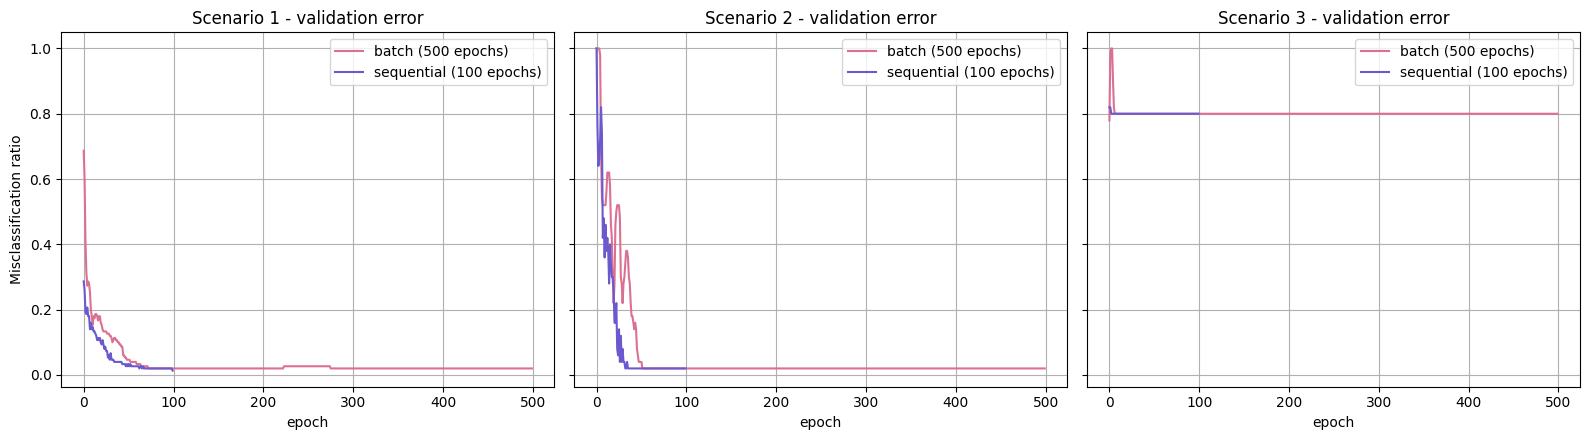

In [16]:
HIDDEN = 10

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for k, sc in enumerate([1, 2, 3]):
    train_idx, val_idx = subsample(features_no_bias, labels, sc)

    _, W0 = get_initial_weights((HIDDEN, 2), 0.5)
    _, V0 = get_initial_weights((1, HIDDEN), 0.5)

    _, _, hist_batch = train_backpropagation(
        features[:, train_idx], labels[:, train_idx], W0.copy(), V0.copy(),
        epochs=500, lr=0.05, mode="batch",
        val_features=features[:, val_idx], val_labels=labels[:, val_idx])

    _, _, hist_seq = train_backpropagation(
        features[:, train_idx], labels[:, train_idx], W0.copy(), V0.copy(),
        epochs=100, lr=0.05, mode="sequential",
        val_features=features[:, val_idx], val_labels=labels[:, val_idx])

    axes[k].plot(hist_batch["mis_val"], color="palevioletred", label="batch (500 epochs)")
    axes[k].plot(hist_seq["mis_val"],   color="slateblue",     label="sequential (100 epochs)")
    axes[k].set_title("Scenario %d - validation error" % sc)
    axes[k].set_xlabel("epoch"); axes[k].grid(True); axes[k].legend()

    print("Scenario %d -> final validation misclassification: batch %.4f | sequential %.4f"
          % (sc, hist_batch["mis_val"][-1], hist_seq["mis_val"][-1]))

axes[0].set_ylabel("Misclassification ratio")
plt.tight_layout(); plt.show()

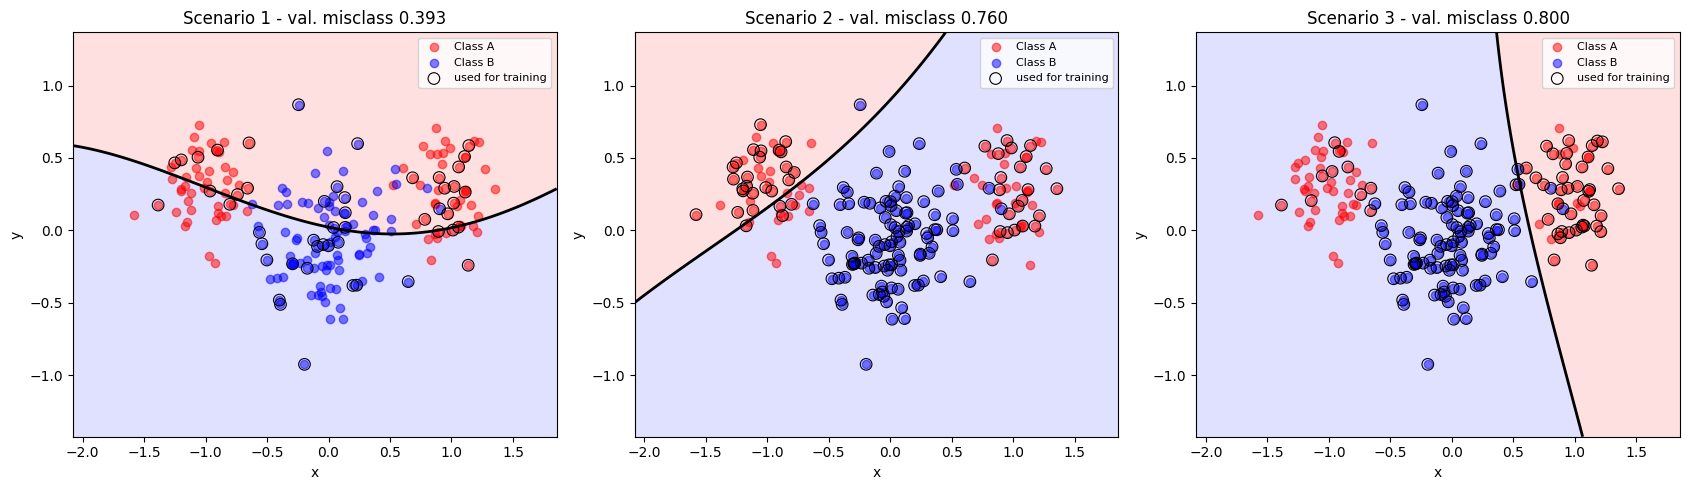

In [17]:
def plot_decision_boundary(W, V, features_no_bias, labels, train_idx=None, ax=None, title=""):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    pad = 0.5
    x_min, x_max = features_no_bias[0].min() - pad, features_no_bias[0].max() + pad
    y_min, y_max = features_no_bias[1].min() - pad, features_no_bias[1].max() + pad

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.vstack([xx.ravel(), yy.ravel(), np.ones(xx.size)])

    _, Z = forward_pass(grid, W, V)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-1, 0, 1], colors=["blue", "red"], alpha=0.12)
    ax.contour(xx, yy, Z, levels=[0], colors="black", linewidths=2)

    A = labels[0] == 1
    B = labels[0] == -1
    ax.scatter(features_no_bias[0, A], features_no_bias[1, A], color="red",  alpha=0.5, label="Class A")
    ax.scatter(features_no_bias[0, B], features_no_bias[1, B], color="blue", alpha=0.5, label="Class B")

    if train_idx is not None:
        ax.scatter(features_no_bias[0, train_idx], features_no_bias[1, train_idx],
                   facecolors="none", edgecolors="black", s=70, linewidths=0.8,
                   label="used for training")

    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    return ax


fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for k, sc in enumerate([1, 2, 3]):
    train_idx, val_idx = subsample(features_no_bias, labels, sc)

    _, W = get_initial_weights((HIDDEN, 2), 0.5)
    _, V = get_initial_weights((1, HIDDEN), 0.5)
    W, V, _ = train_backpropagation(features[:, train_idx], labels[:, train_idx], W, V)

    _, mis_v = compute_metrics(features[:, val_idx], labels[:, val_idx], W, V)
    plot_decision_boundary(W, V, features_no_bias, labels, train_idx, ax=axes[k],
                           title="Scenario %d - val. misclass %.3f" % (sc, mis_v))

plt.tight_layout()
plt.savefig("decision_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.1.3 Function approximation

#### Generate and plot data 
- function:  $f(x,y) = e^{-(x^2+y^2)/10}-0.5, \quad (x,y) \in \mathbb{R}^2$

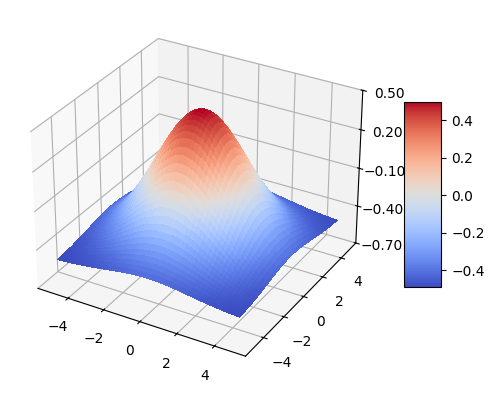

[[-5.  -4.9 -4.8 ...  4.7  4.8  4.9]
 [-5.  -4.9 -4.8 ...  4.7  4.8  4.9]
 [-5.  -4.9 -4.8 ...  4.7  4.8  4.9]
 ...
 [-5.  -4.9 -4.8 ...  4.7  4.8  4.9]
 [-5.  -4.9 -4.8 ...  4.7  4.8  4.9]
 [-5.  -4.9 -4.8 ...  4.7  4.8  4.9]]


In [18]:
from matplotlib.ticker import LinearLocator

# Generate data
X = np.arange(-5, 5, 0.1)
Y = np.arange(-5, 5, 0.1)

X, Y = np.meshgrid(X, Y)

exp = -(X**2 + Y**2) / 10
Z = np.e**exp - 0.5


# Plot the surface
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

surf = ax.plot_surface(X, Y, Z, cmap="coolwarm", linewidth=0, antialiased=False)

ax.set_zlim(-0.7, 0.5)
ax.zaxis.set_major_locator(LinearLocator(5))
ax.zaxis.set_major_formatter('{x:.02f}')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

print(X)

#### 3.1.3.1. The First Experiment
Vary the number of nodes in the hidden layer from 1 to 25 (every few) and try to observe any trends. What happens when you have very few (less than 5) or very many (more than 20) hidden nodes? Can you explain your observations? Try to make a model comparison - what error estimates and how would you compare them to identify the ”best” model?

<>:79: SyntaxWarning: invalid escape sequence '\p'
<>:79: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_127/3253883889.py:79: SyntaxWarning: invalid escape sequence '\p'
  label='$\pm$ Std Dev'


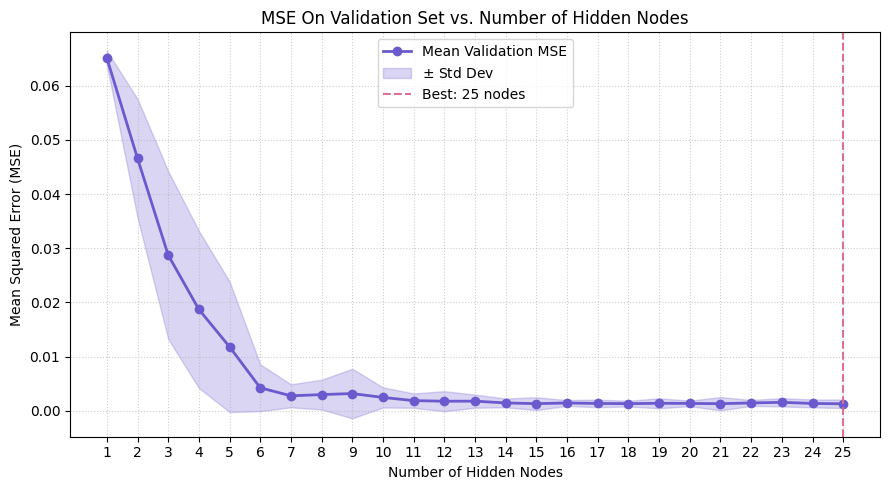

Lowest MSE (0.001299) was achieved for 25 nodes.


In [19]:
np.random.seed(13)

HIDDEN_NODES = np.arange(1, 26, 1)
RANDOM_INIT = 30

n_samples = X.size
n_features = 2
features = np.vstack([X.ravel(), Y.ravel(), np.ones(n_samples)])
labels = Z.ravel()

input_dim = features.shape[0] 

# Shuffle
indices = np.random.permutation(n_samples)
labels = labels[indices]
features = features[:, indices]

# Split into training and eval set
train_proportion = 0.7
split_index = int(train_proportion * n_samples)
features_train = features[:, :split_index]
features_val = features[:, split_index:]
labels_train = labels[:split_index]
labels_val = labels[split_index:]

best_error = np.inf
best_hidden_dim = 0

final_mses = []
final_std = []


for hidden_dim in HIDDEN_NODES:
    MSEs = []
    for i in range(RANDOM_INIT):

        _, W = get_initial_weights((hidden_dim, n_features), 1)
        _, V = get_initial_weights((1, hidden_dim), 1) 

        W_trained, V_trained, _ = train_backpropagation(
            features=features_train.copy(),
            labels=labels_train.copy(),
            W=W.copy(),
            V=V.copy(),
        )

        _, predictions = forward_pass(
            features_val.copy(), 
            W_trained.copy(), 
            V_trained.copy()
        )

        mse = np.mean((predictions.ravel() - labels_val)**2)
        MSEs.append(mse)
    
    avg_mse = np.mean(MSEs)
    std_mse = np.std(MSEs)

    final_mses.append(avg_mse)
    final_std.append(std_mse)

    if avg_mse < best_error:
        best_error = avg_mse
        best_hidden_dim = hidden_dim

final_mses = np.array(final_mses)
final_std = np.array(final_std)

plt.figure(figsize=(9, 5))

plt.plot(HIDDEN_NODES, final_mses, marker='o', color='slateblue', linewidth=2, label='Mean Validation MSE')

plt.fill_between(
    HIDDEN_NODES, 
    final_mses - final_std, 
    final_mses + final_std, 
    color='slateblue', 
    alpha=0.25, 
    label='$\pm$ Std Dev'
)

plt.axvline(best_hidden_dim, color='palevioletred', linestyle='--', label=f'Best: {best_hidden_dim} nodes')

plt.title('MSE On Validation Set vs. Number of Hidden Nodes')
plt.xlabel('Number of Hidden Nodes')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(HIDDEN_NODES)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Lowest MSE ({best_error:.6f}) was achieved for {best_hidden_dim} nodes.")

#### 3.1.3.2 The Second Experiment
For the selected ”best” model, run experiments with varying number of the training samples, e.g. from 80% down to 20% of all the dataset.

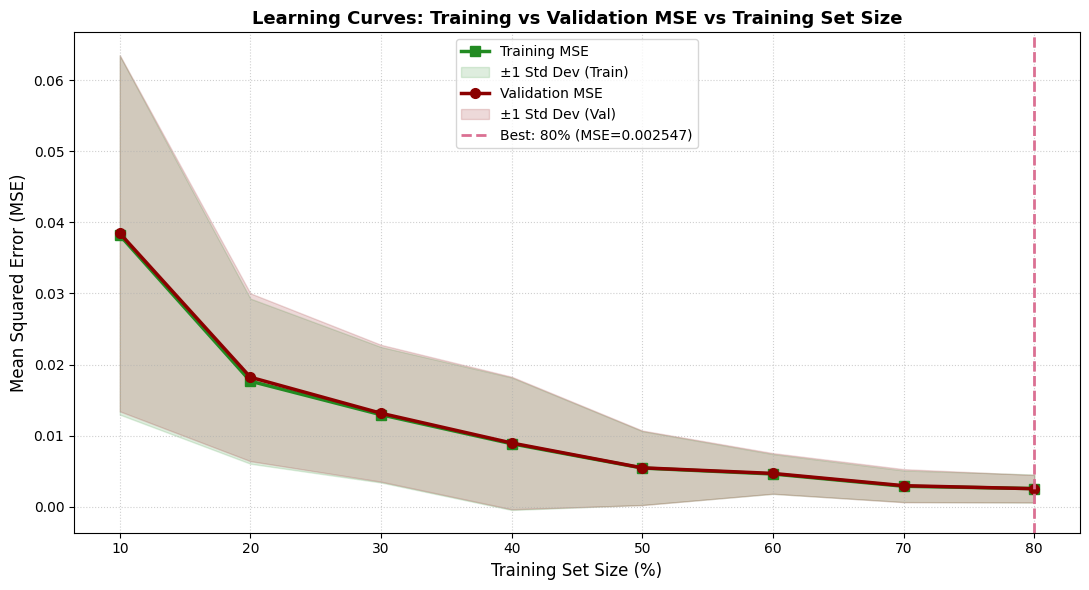

In [20]:
np.random.seed(13)

TRAINING_PORTIONS = np.arange(0.1, 0.9, 0.1)
RANDOM_INIT = 30

n_samples = X.size
n_features = 2  
features = np.vstack([X.ravel(), Y.ravel(), np.ones(n_samples)])
labels = Z.ravel()

input_dim = features.shape[0] 

original_features = features.copy()
original_labels = labels.copy()

best_error = np.inf
best_proportion = 0

MSE_train = []
MSE_train_std = [] 
MSE_val = []
MSE_val_std = []  

for train_proportion in TRAINING_PORTIONS:
    indices = np.random.permutation(n_samples)
    shuffled_labels = original_labels[indices]
    shuffled_features = original_features[:, indices]

    split_index = int(train_proportion * n_samples)
    features_train = shuffled_features[:, :split_index]
    features_val = shuffled_features[:, split_index:]
    labels_train = shuffled_labels[:split_index]
    labels_val = shuffled_labels[split_index:]

    MSE_T = []
    MSE_V = []

    best_hidden_dim = 8
    
    for i in range(RANDOM_INIT):

        _, W = get_initial_weights((best_hidden_dim, n_features), 1)
        _, V = get_initial_weights((1, best_hidden_dim), 1) 

        W_trained, V_trained, _ = train_backpropagation(
            features=features_train.copy(),
            labels=labels_train.copy(),
            W=W.copy(),
            V=V.copy(),
        )

        _, train_predictions = forward_pass(
            features_train.copy(),
            W_trained.copy(),
            V_trained.copy()
        )
        mse_train = np.mean((train_predictions.ravel() - labels_train)**2)
        MSE_T.append(mse_train)

        _, predictions = forward_pass(
            features_val.copy(), 
            W_trained.copy(), 
            V_trained.copy()
        )
        mse_val = np.mean((predictions.ravel() - labels_val)**2)
        MSE_V.append(mse_val)
    

    MSE_T_avg = np.mean(MSE_T)
    MSE_T_std = np.std(MSE_T)
    MSE_train.append(MSE_T_avg)
    MSE_train_std.append(MSE_T_std)

    MSE_V_avg = np.mean(MSE_V)
    MSE_V_std = np.std(MSE_V) 
    MSE_val.append(MSE_V_avg)
    MSE_val_std.append(MSE_V_std)

    if MSE_V_avg < best_error:
        best_error = MSE_V_avg
        best_proportion = train_proportion

MSE_train = np.array(MSE_train)
MSE_train_std = np.array(MSE_train_std)
MSE_val = np.array(MSE_val)
MSE_val_std = np.array(MSE_val_std)

plt.figure(figsize=(11, 6))

plt.plot(TRAINING_PORTIONS * 100, MSE_train, marker='s', color='forestgreen', 
         linewidth=2.5, markersize=7, label='Training MSE')

plt.fill_between(
    TRAINING_PORTIONS * 100,
    MSE_train - MSE_train_std,
    MSE_train + MSE_train_std,
    color='forestgreen',
    alpha=0.15,
    label='±1 Std Dev (Train)'
)

plt.plot(TRAINING_PORTIONS * 100, MSE_val, marker='o', color='darkred', 
         linewidth=2.5, markersize=7, label='Validation MSE')
plt.fill_between(
    TRAINING_PORTIONS * 100,
    MSE_val - MSE_val_std,
    MSE_val + MSE_val_std,
    color='darkred',
    alpha=0.15,
    label='±1 Std Dev (Val)'
)

plt.axvline(best_proportion * 100, color='palevioletred', linestyle='--', 
            linewidth=2, label=f'Best: {best_proportion*100:.0f}% (MSE={best_error:.6f})')

plt.title('Learning Curves: Training vs Validation MSE vs Training Set Size', 
          fontsize=13, fontweight='bold')
plt.xlabel('Training Set Size (%)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(TRAINING_PORTIONS * 100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

LR = 0.001, alpha = 0.0, train MSE = 0.079930, validation MSE = 0.079204


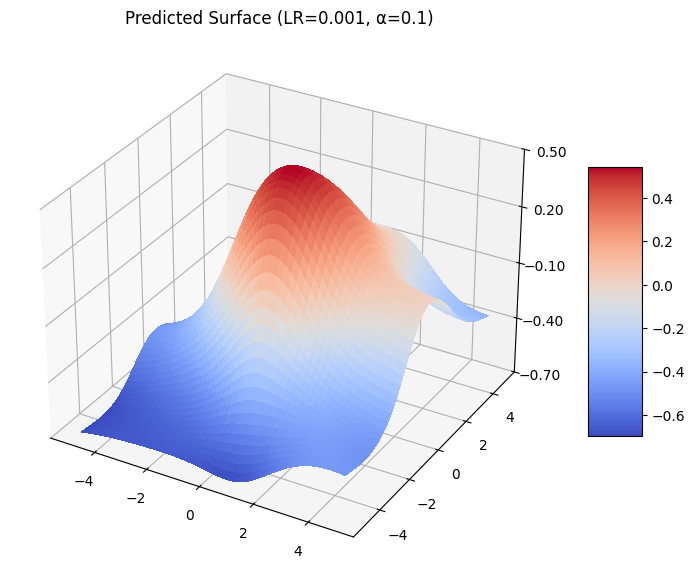

LR = 0.001, alpha = 0.1, train MSE = 0.037737, validation MSE = 0.038395
LR = 0.001, alpha = 0.3, train MSE = 0.011438, validation MSE = 0.011544
LR = 0.001, alpha = 0.5, train MSE = 0.003388, validation MSE = 0.003249
LR = 0.001, alpha = 0.7, train MSE = 0.002455, validation MSE = 0.002406


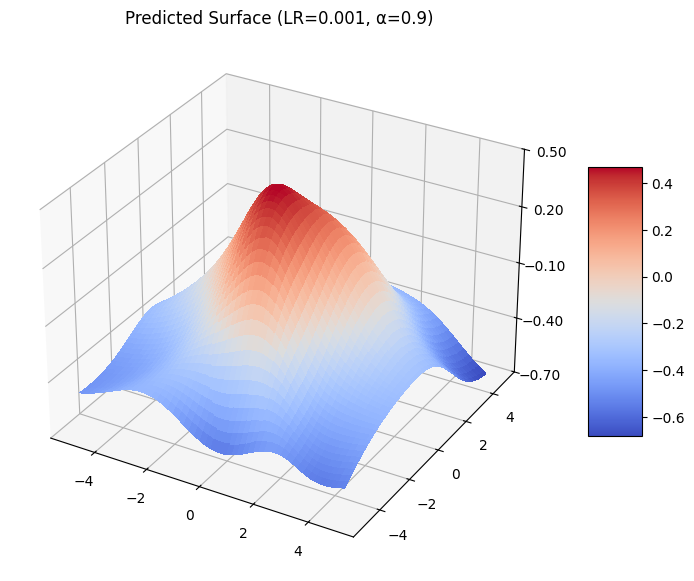

LR = 0.001, alpha = 0.9, train MSE = 0.002704, validation MSE = 0.002655
LR = 0.005, alpha = 0.0, train MSE = 0.440873, validation MSE = 0.432345


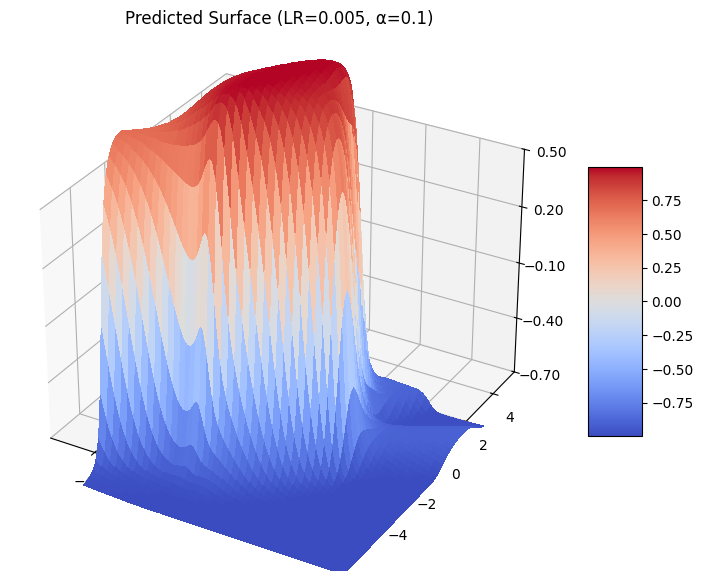

LR = 0.005, alpha = 0.1, train MSE = 0.406615, validation MSE = 0.403803
LR = 0.005, alpha = 0.3, train MSE = 0.449616, validation MSE = 0.449164
LR = 0.005, alpha = 0.5, train MSE = 0.393700, validation MSE = 0.388614
LR = 0.005, alpha = 0.7, train MSE = 0.319346, validation MSE = 0.321243


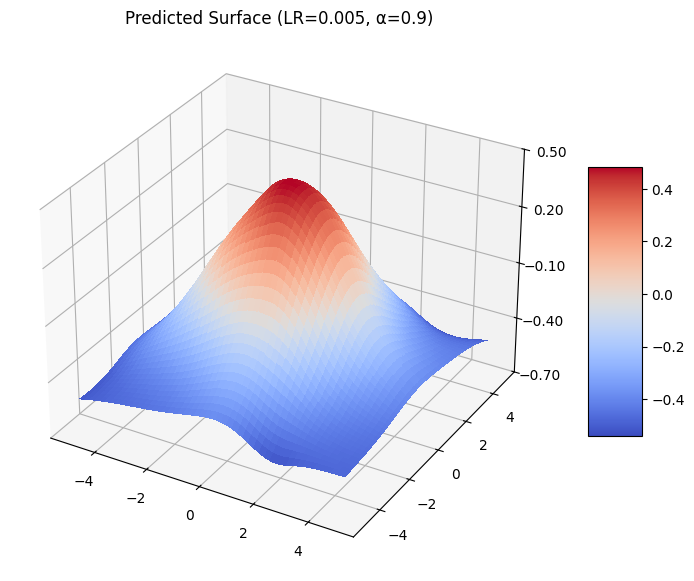

LR = 0.005, alpha = 0.9, train MSE = 0.000430, validation MSE = 0.000445
LR = 0.010, alpha = 0.0, train MSE = 0.710660, validation MSE = 0.691803
LR = 0.010, alpha = 0.1, train MSE = 0.709514, validation MSE = 0.690711
LR = 0.010, alpha = 0.3, train MSE = 0.487170, validation MSE = 0.493923
LR = 0.010, alpha = 0.5, train MSE = 0.683859, validation MSE = 0.689365
LR = 0.010, alpha = 0.7, train MSE = 0.547587, validation MSE = 0.531371
LR = 0.010, alpha = 0.9, train MSE = 0.130200, validation MSE = 0.129846
LR = 0.050, alpha = 0.0, train MSE = 0.716477, validation MSE = 0.701003
LR = 0.050, alpha = 0.1, train MSE = 0.742057, validation MSE = 0.735540
LR = 0.050, alpha = 0.3, train MSE = 0.682432, validation MSE = 0.668020
LR = 0.050, alpha = 0.5, train MSE = 0.757602, validation MSE = 0.766781
LR = 0.050, alpha = 0.7, train MSE = 0.656499, validation MSE = 0.658540
LR = 0.050, alpha = 0.9, train MSE = 0.576989, validation MSE = 0.576469


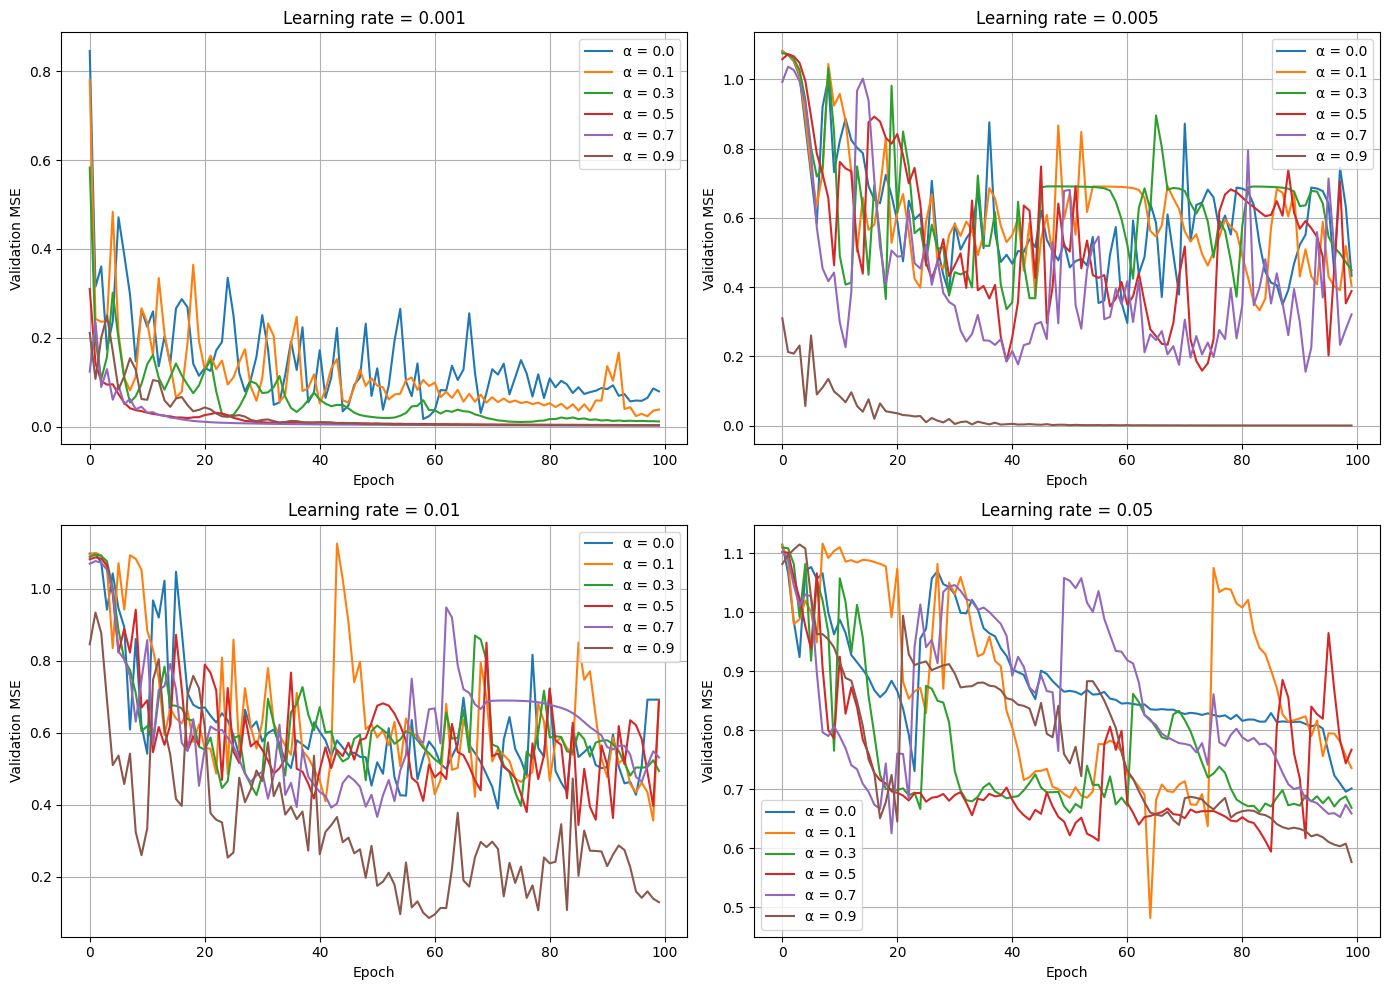

In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(13)

ALPHAs = np.arange(0.1, 1.0, 0.2)
ALPHAs = np.insert(ALPHAs, 0, 0)
LRs = np.array([0.001, 0.005, 0.01, 0.05])

n_samples = X.size
n_features = 2

features = np.vstack([
    X.ravel(),
    Y.ravel(),
    np.ones(n_samples)
])
labels = Z.ravel()

# Shuffle
indices = np.random.permutation(n_samples)
labels = labels[indices]
features = features[:, indices]

# Split into training and validation set
train_proportion = 0.7
split_index = int(train_proportion * n_samples)

features_train = features[:, :split_index]
features_val = features[:, split_index:]

labels_train = labels[:split_index]
labels_val = labels[split_index:]

# Best architecture from Task 1
best_hidden_dim = 8

# Same initial weights for every experiment
_, W0 = get_initial_weights((best_hidden_dim, n_features), 1)
_, V0 = get_initial_weights((1, best_hidden_dim), 1)

summary = {}

for lr_try in LRs:
    summary[lr_try] = {}

    for alp in ALPHAs:

        # alpha is a global variable
        alpha = alp

        W_trained, V_trained, history = train_backpropagation(
            features=features_train.copy(),
            labels=labels_train.copy(),
            W=W0.copy(),
            V=V0.copy(),
            lr=lr_try,
            val_features=features_val.copy(),
            val_labels=labels_val.copy()
        )

        if np.isclose(lr_try, 0.001) or np.isclose(lr_try, 0.005):
            if np.isclose(alp, 0.9) or np.isclose(alp, 0.1):
                # 1. Recreate the unshuffled features so they align perfectly with the X, Y meshgrids
                unshuffled_features = np.vstack([
                    X.ravel(),
                    Y.ravel(),
                    np.ones(n_samples)
                ])
                
                # 2. Get predictions using the trained weights
                _, predictions = forward_pass(unshuffled_features, W_trained, V_trained)

                # 3. Reshape the 1D predictions back into the 2D shape of X and Y
                Z_pred = predictions.reshape(X.shape)
                
                # 4. Plot the 3D surface
                fig = plt.figure(figsize=(10, 7))
                ax = fig.add_subplot(111, projection="3d")
                
                surf = ax.plot_surface(X, Y, Z_pred, cmap="coolwarm", linewidth=0, antialiased=False)
                
                ax.set_title(f"Predicted Surface (LR={lr_try}, α={alp:.1f})")
                ax.set_zlim(-0.7, 0.5)
                ax.zaxis.set_major_locator(LinearLocator(5))
                ax.zaxis.set_major_formatter('{x:.02f}')
                fig.colorbar(surf, shrink=0.5, aspect=5)
                
                plt.show()


        train_mse = history["mse_train"][-1]
        val_mse = history["mse_val"][-1]

        summary[lr_try][alp] = {
            "train_mse": train_mse,
            "val_mse": val_mse,
            "history": history
        }

        print(
            f"LR = {lr_try:.3f}, "
            f"alpha = {alp:.1f}, "
            f"train MSE = {train_mse:.6f}, "
            f"validation MSE = {val_mse:.6f}"
        )

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, lr_try in zip(axes.ravel(), LRs):

    for alp in ALPHAs:

        history = summary[lr_try][alp]["history"]

        ax.plot(
            history["mse_val"],
            label=f"α = {alp:.1f}"
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation MSE")
    ax.set_title(f"Learning rate = {lr_try}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# 4 \- MLP network for chaotic time\-series prediction

In [22]:
from functools import lru_cache
# Mackey-Glass time series
@lru_cache(maxsize = None)
def mackey(t):
    if t < 0:
        return 0
    elif t == 0:
        return 1.5
    t = t - 1
    x0 = mackey(t)
    x25 = mackey(t - 25)
    return x0 + (0.2 * x25 / (1 + x25 ** 10) - (0.1 * x0))
    
assert mackey(0) == 1.5
assert mackey(-1) == 0
assert mackey(1) == 1.35

### 4\.1 Data

In [23]:
import torch
import torch.nn as nn

In [24]:
full_mackey = np.array([mackey(t) for t in range(0, 1506)]) # all values for dynamic array filling
t_range = range(301, 1501) # t from 301 to 1500

features = np.array([
    [full_mackey[i-20] for i in t_range], 
    [full_mackey[i-15] for i in t_range], 
    [full_mackey[i-10] for i in t_range], 
    [full_mackey[i-5] for i in t_range], 
    [full_mackey[i] for i in t_range]
    ]).T 
labels = np.array([full_mackey[i+5] for i in t_range])

assert features.shape == (1200, 5)
assert labels.shape == (1200, )

features_train = features[:750]
features_validate = features[750:1000]
features_test = features[1000:]
labels_train = labels[:750]
labels_validate = labels[750:1000]
labels_test = labels[1000:]

X_train = torch.tensor(features_train, dtype = torch.float32)
X_val = torch.tensor(features_validate, dtype = torch.float32)
X_test = torch.tensor(features_test, dtype = torch.float32)
Y_train = torch.tensor(labels_train, dtype = torch.float32).unsqueeze(1)
Y_val = torch.tensor(labels_validate, dtype = torch.float32).unsqueeze(1)
Y_test = torch.tensor(labels_test, dtype = torch.float32).unsqueeze(1)

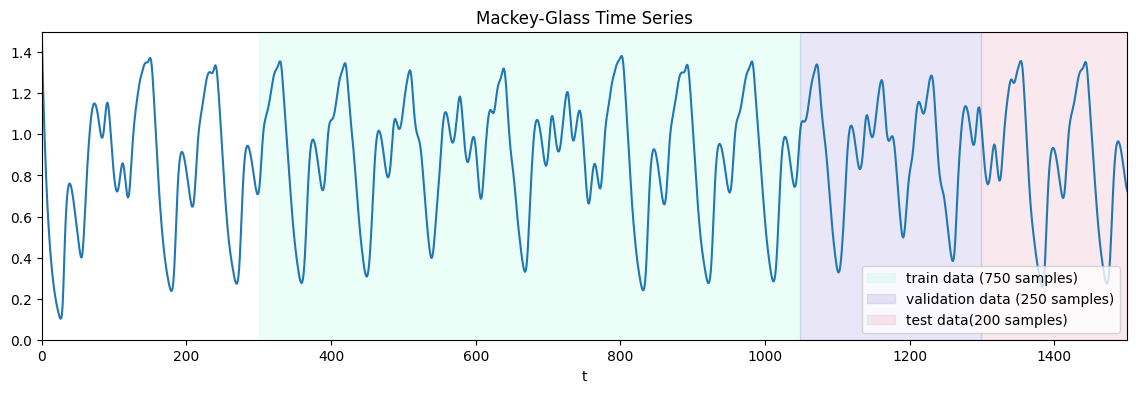

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(full_mackey)
plt.axvspan(300, 1049, alpha=0.15, color='aquamarine',  label='train data (750 samples)')
plt.axvspan(1049, 1299, alpha=0.15, color='slateblue', label='validation data (250 samples)')
plt.axvspan(1299, 1504, alpha=0.15, color='palevioletred',  label='test data(200 samples)')
plt.xlim(0, 1500)
plt.ylim(0, 1.5)
plt.title('Mackey-Glass Time Series')
plt.xlabel('t')
plt.legend()
plt.show()

### 4\.2 Network configuration

In [26]:
class MLP(nn.Module):
    def __init__(self, hidden_size_1, hidden_size_2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, hidden_size_1),
            nn.Sigmoid(),
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.Sigmoid(),
            nn.Linear(hidden_size_2, 1),
        )
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.net(x)

In [27]:
import copy

In [28]:


def evaluate (hidden_size_1 = 9, hidden_size_2 = 5, lr = 0.06, lambdaL2 = 0.0001, earlyStopping = 20, epochs = 1000, info = False, test_plot = False):
    if info:
        print("-----------------------")
    model = MLP(hidden_size_1, hidden_size_2)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=lambdaL2)
    best_loss = float('inf')
    earlyStopping_count = 0
    best_weights = None

    train_loss = []
    validation_loss = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred_train = model(X_train)
        loss_train = criterion(pred_train, Y_train)
        loss_train.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_mse = criterion(model(X_train), Y_train).item()
            loss_val = criterion(model(X_val), Y_val).item()

        train_loss.append(train_mse)
        validation_loss.append(loss_val)

        if loss_val < best_loss:
            best_loss = loss_val
            earlyStopping_count = 0
            best_weights = copy.deepcopy(model.state_dict())
        else:
            earlyStopping_count += 1
            if earlyStopping_count >= earlyStopping:
                if info:
                    print("Early stoppng at epoch: ", epoch)
                break
    model.load_state_dict(best_weights)
    if(info):
        print("Layer 1: ", hidden_size_1, "    Layer 2: ", hidden_size_2)
        print("Learning rate: ", lr, "    L2 weight decay: ", lambdaL2)
        print("Best validation MSE: ", best_loss)
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test)
        test_mse = criterion(pred_test, Y_test).item()
    if(info):
        print("Test MSE: ", test_mse)
        plt.figure(figsize=(10, 4))
        plt.plot(train_loss, label='train MSE', color = "aquamarine")
        plt.plot(validation_loss,   label='val MSE', color = "palevioletred")
        plt.xlim(0)
        plt.ylim(0, 0.1)
        plt.xlabel('epoch')

        plt.ylabel('MSE')
        plt.legend()
        plt.title('Learning curves')
        plt.show()
    if test_plot:
        y_test_np = Y_test.detach().cpu().numpy() 
        pred_test_np = pred_test.detach().cpu().numpy() 
        plt.figure(figsize=(10, 5)) 
        plt.plot( y_test_np, label="Test data", color = "aquamarine"  ) 
        plt.plot( pred_test_np, label="Predictions", color = "palevioletred" ) 
        plt.xlabel("Test sample") 
        plt.ylabel("Target") 
        plt.ylim(0)

        plt.title("Test data vs. predictions") 
        plt.legend() 
        plt.tight_layout() 
        plt.show()
    return best_loss



### 4\.3 Simulations and evaluation

In [29]:
# this will run for 40 minutes
'''import numpy as np
import matplotlib.pyplot as plt

# Settings
n_runs = 20
hidden_sizes = range(1, 10)

# Store all individual results
# Shape: [hidden_size_1, hidden_size_2, run]
all_results = np.zeros((9, 9, n_runs))

for hidden_size_1 in hidden_sizes:
    print("check ", hidden_size_1, "/9")
    for hidden_size_2 in hidden_sizes:



        for run in range(n_runs):

            validation_loss = evaluate(
                hidden_size_1=hidden_size_1,
                hidden_size_2=hidden_size_2,
                lr=0.04,
                lambdaL2=0.0001,
                earlyStopping=30,
                epochs=500,
                info=False
            )

            all_results[
                hidden_size_1 - 1,
                hidden_size_2 - 1,
                run
            ] = validation_loss
'''

'import numpy as np\nimport matplotlib.pyplot as plt\n\n# Settings\nn_runs = 20\nhidden_sizes = range(1, 10)\n\n# Store all individual results\n# Shape: [hidden_size_1, hidden_size_2, run]\nall_results = np.zeros((9, 9, n_runs))\n\nfor hidden_size_1 in hidden_sizes:\n    print("check ", hidden_size_1, "/9")\n    for hidden_size_2 in hidden_sizes:\n\n\n\n        for run in range(n_runs):\n\n            validation_loss = evaluate(\n                hidden_size_1=hidden_size_1,\n                hidden_size_2=hidden_size_2,\n                lr=0.04,\n                lambdaL2=0.0001,\n                earlyStopping=30,\n                epochs=500,\n                info=False\n            )\n\n            all_results[\n                hidden_size_1 - 1,\n                hidden_size_2 - 1,\n                run\n            ] = validation_loss\n'

In [30]:
'''# Mean test MSE
mean_results = np.mean(all_results, axis=2)

# Standard deviation of test MSE
std_results = np.std(all_results, axis=2)

# Minimum and maximum, useful for analysis
min_results = np.min(all_results, axis=2)
max_results = np.max(all_results, axis=2)

from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "bessst_colors",
    ["aquamarine", "slateblue", "palevioletred"]
)

fig, ax = plt.subplots(figsize=(12, 10))

# Color based on mean MSE
im = ax.imshow(
    mean_results,
    cmap=cmap
)

# Axis labels
ax.set_xlabel("Hidden Layer 2 size")
ax.set_ylabel("Hidden Layer 1 size")
ax.set_title(
    "Grid Search on validation data (mean performance over 20 random initializations)"
)

# Ticks
ax.set_xticks(np.arange(9))
ax.set_yticks(np.arange(9))

ax.set_xticklabels(np.arange(1, 10))
ax.set_yticklabels(np.arange(1, 10))

# Put mean ± standard deviation in each cell
for i in range(9):
    for j in range(9):

        ax.text(
            j,
            i,
            f"{mean_results[i, j]:.4f}\n"
            f"± {std_results[i, j]:.4f}",
            ha="center",
            va="center",
            fontsize=9
        )

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean Validation error")

plt.tight_layout()
plt.show()
'''

'# Mean test MSE\nmean_results = np.mean(all_results, axis=2)\n\n# Standard deviation of test MSE\nstd_results = np.std(all_results, axis=2)\n\n# Minimum and maximum, useful for analysis\nmin_results = np.min(all_results, axis=2)\nmax_results = np.max(all_results, axis=2)\n\nfrom matplotlib.colors import LinearSegmentedColormap\n\ncmap = LinearSegmentedColormap.from_list(\n    "bessst_colors",\n    ["aquamarine", "slateblue", "palevioletred"]\n)\n\nfig, ax = plt.subplots(figsize=(12, 10))\n\n# Color based on mean MSE\nim = ax.imshow(\n    mean_results,\n    cmap=cmap\n)\n\n# Axis labels\nax.set_xlabel("Hidden Layer 2 size")\nax.set_ylabel("Hidden Layer 1 size")\nax.set_title(\n    "Grid Search on validation data (mean performance over 20 random initializations)"\n)\n\n# Ticks\nax.set_xticks(np.arange(9))\nax.set_yticks(np.arange(9))\n\nax.set_xticklabels(np.arange(1, 10))\nax.set_yticklabels(np.arange(1, 10))\n\n# Put mean ± standard deviation in each cell\nfor i in range(9):\n    for 

-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.0
Best validation MSE:  0.004645302891731262
Test MSE:  0.005623279605060816


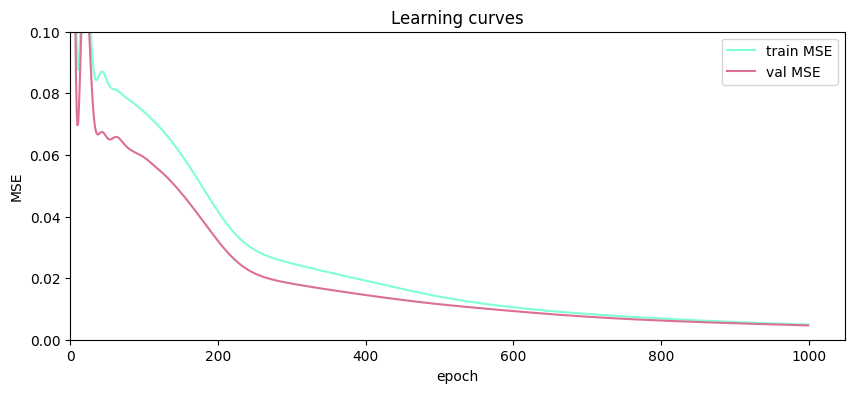

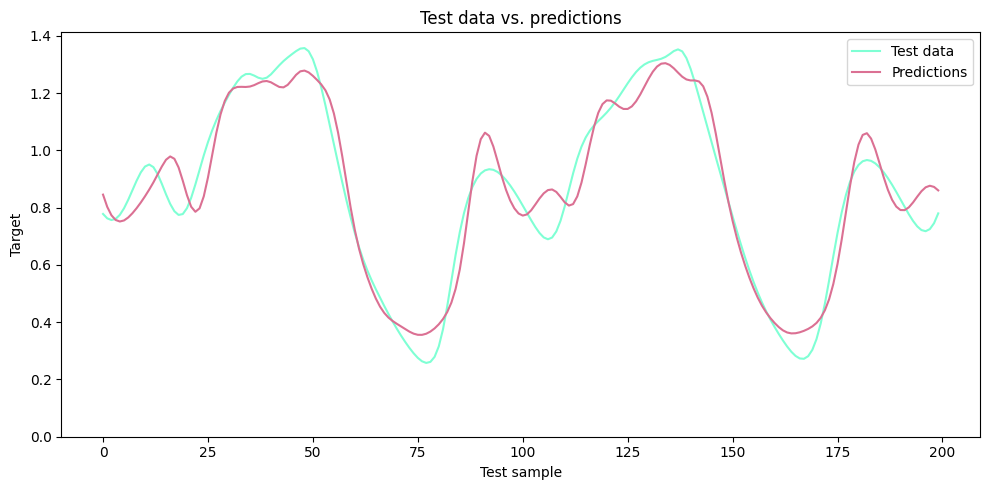

-----------------------
Layer 1:  1     Layer 2:  2
Learning rate:  0.01     L2 weight decay:  0.0
Best validation MSE:  0.012470845133066177
Test MSE:  0.027159912511706352


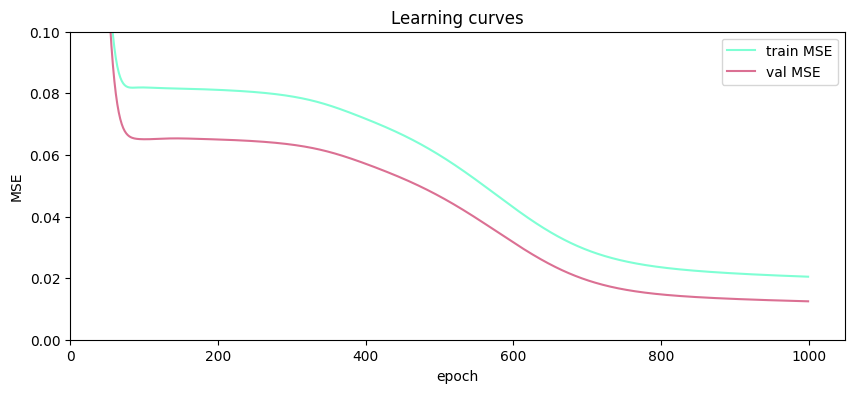

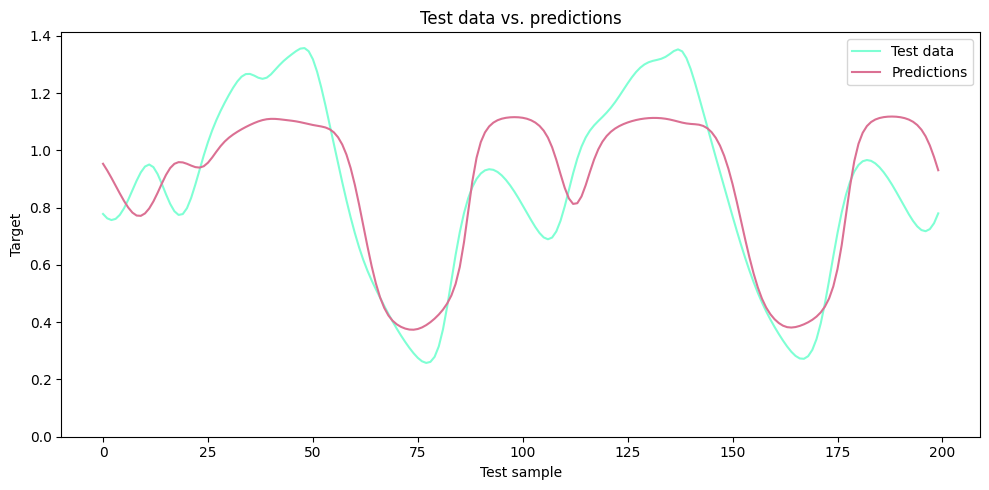

0.012470845133066177

In [31]:
evaluate(
                hidden_size_1=8,
                hidden_size_2=8,
                lr=0.01,
                lambdaL2=0.000,
                earlyStopping=3000,
                epochs=1000,
                info=True,
                test_plot = True
            )
evaluate(
                hidden_size_1=1,
                hidden_size_2=2,
                lr=0.01,
                lambdaL2=0.000,
                earlyStopping=3000,
                epochs=1000,
                info=True,
                test_plot = True
            )

-----------------------
Layer 1:  1     Layer 2:  2
Learning rate:  0.0     L2 weight decay:  0.0
Best validation MSE:  0.707224428653717
Test MSE:  0.6455337405204773


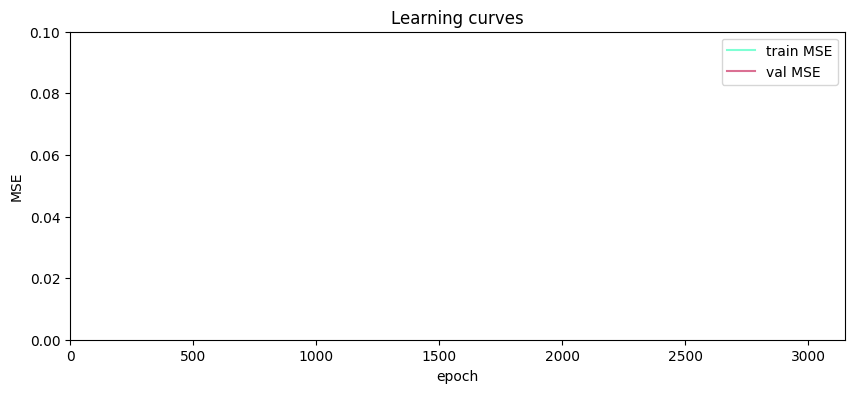

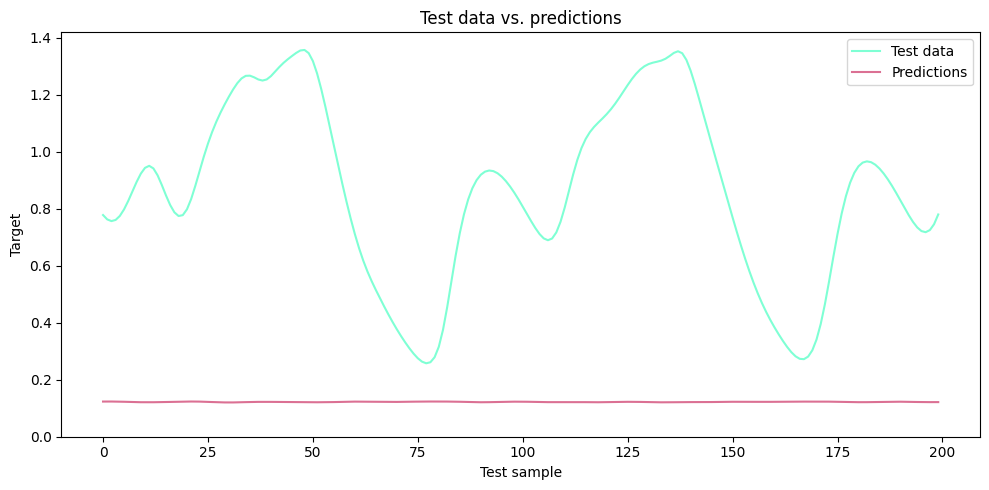

-----------------------
Layer 1:  1     Layer 2:  2
Learning rate:  0.0     L2 weight decay:  0.0
Best validation MSE:  0.08882777392864227
Test MSE:  0.10139021277427673


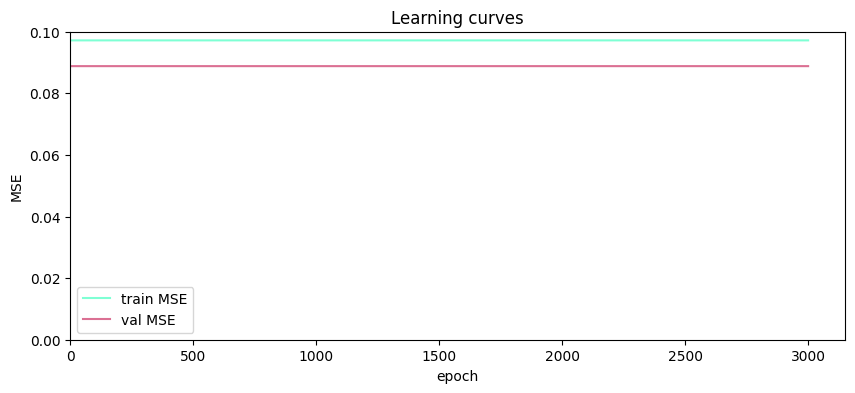

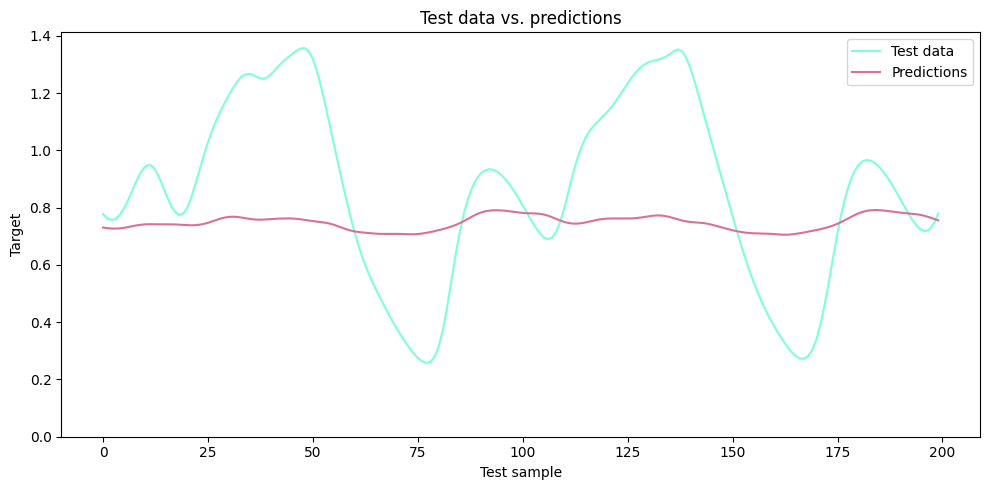

-----------------------
Layer 1:  1     Layer 2:  2
Learning rate:  0.0     L2 weight decay:  0.0
Best validation MSE:  0.8725715279579163
Test MSE:  0.7963354587554932


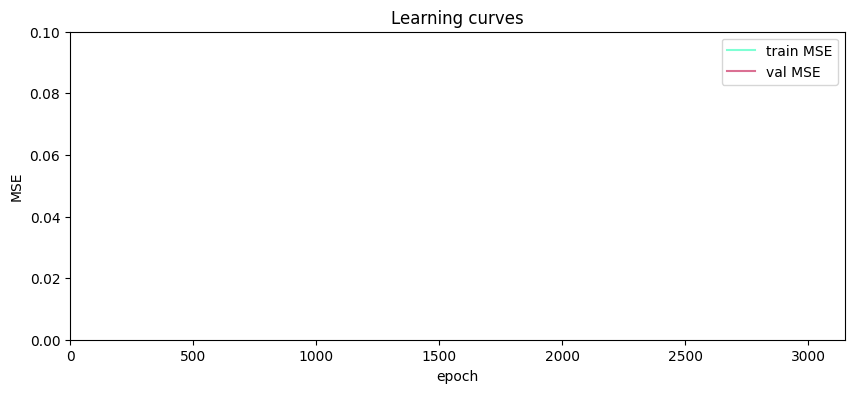

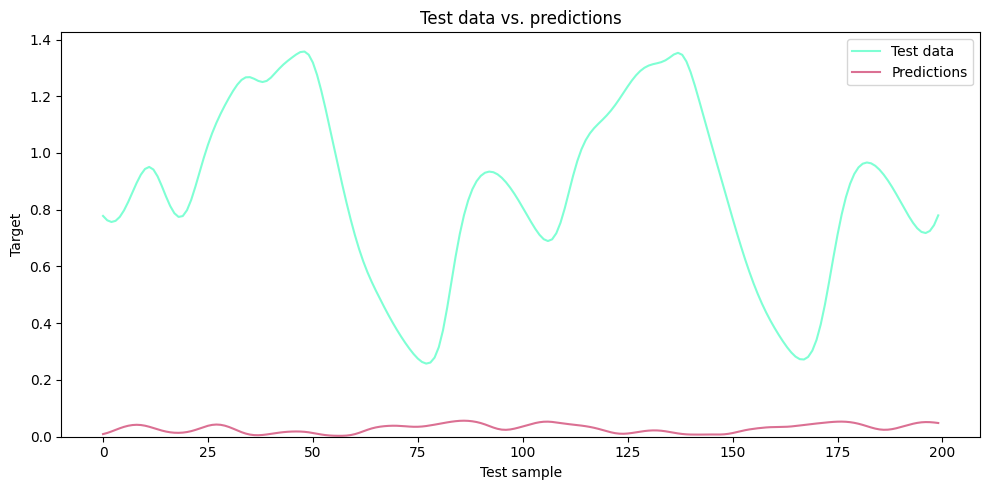

-----------------------
Layer 1:  1     Layer 2:  2
Learning rate:  0.0     L2 weight decay:  0.0
Best validation MSE:  2.0320451259613037
Test MSE:  1.8944675922393799


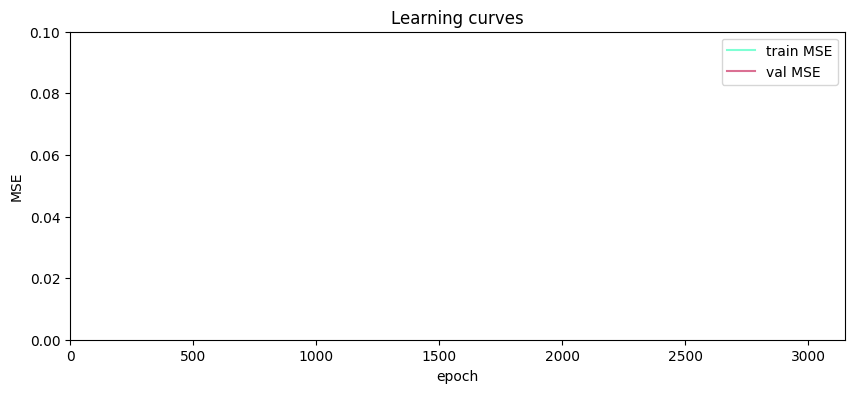

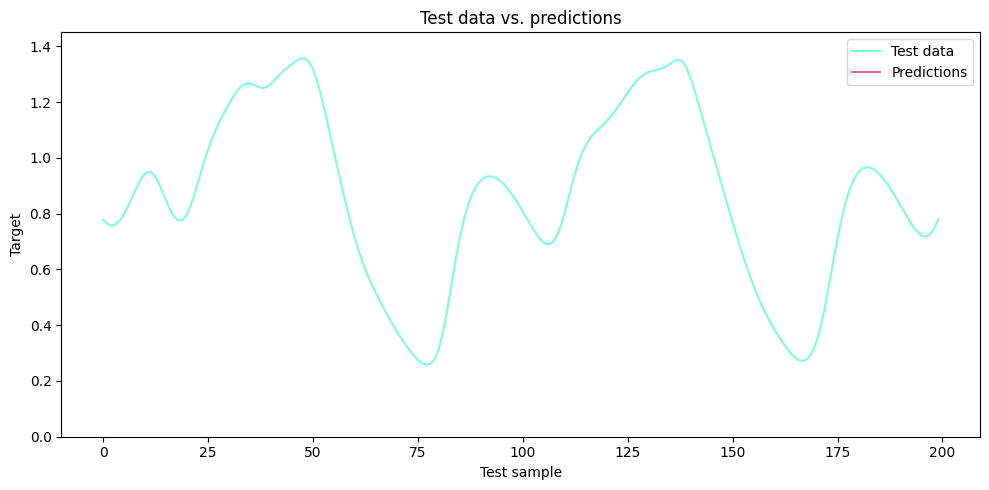

-----------------------
Layer 1:  1     Layer 2:  2
Learning rate:  0.0     L2 weight decay:  0.0
Best validation MSE:  2.27329683303833
Test MSE:  2.1280181407928467


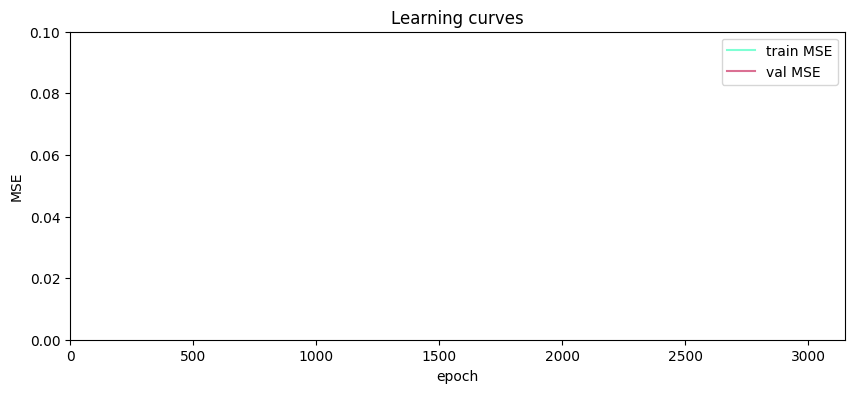

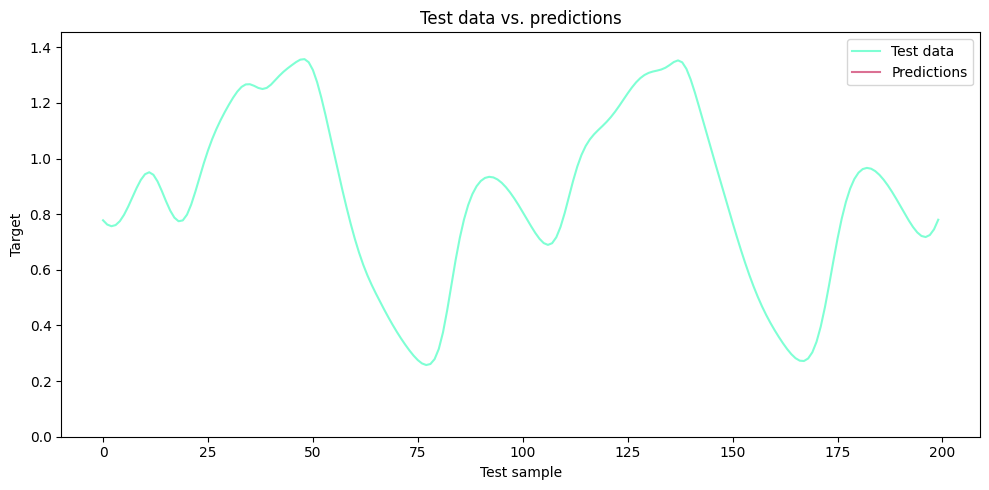

-----------------------
Layer 1:  1     Layer 2:  2
Learning rate:  0.0     L2 weight decay:  0.0
Best validation MSE:  0.184734508395195
Test MSE:  0.26649409532546997


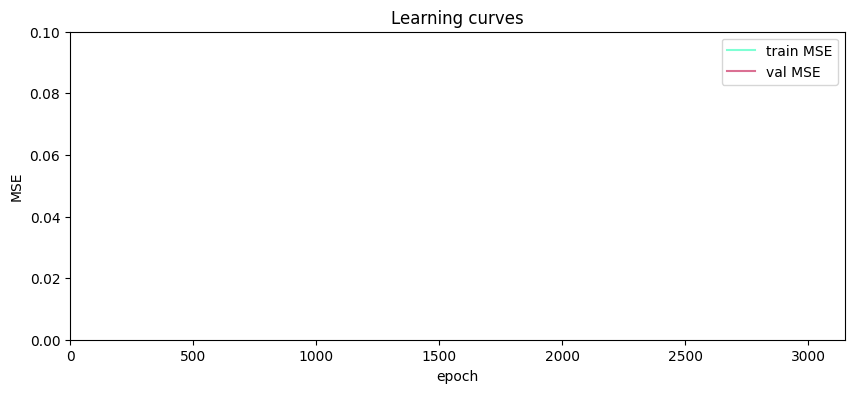

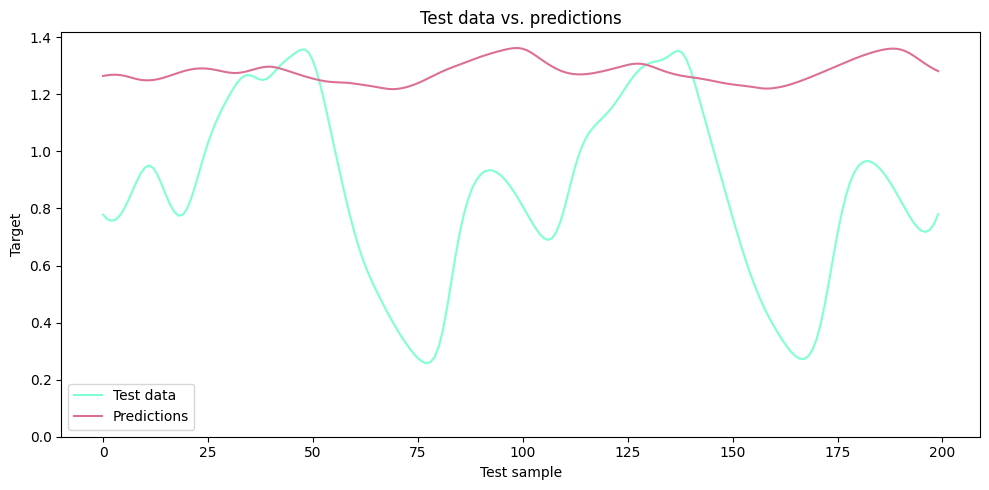

-----------------------
Layer 1:  1     Layer 2:  2
Learning rate:  0.0     L2 weight decay:  0.0
Best validation MSE:  2.7176690101623535
Test MSE:  2.557236433029175


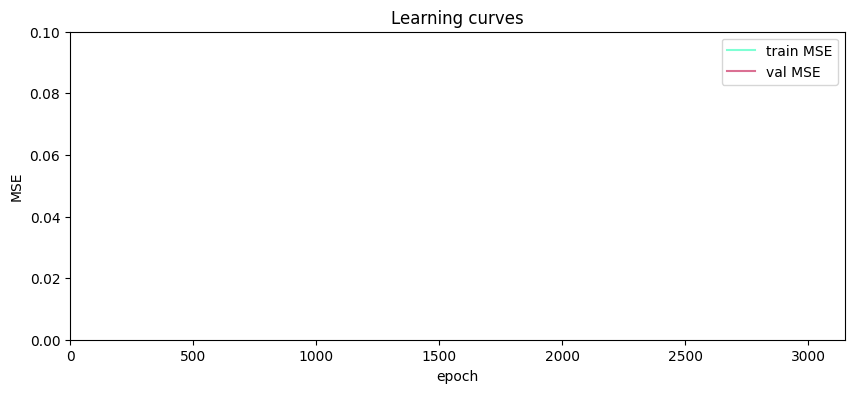

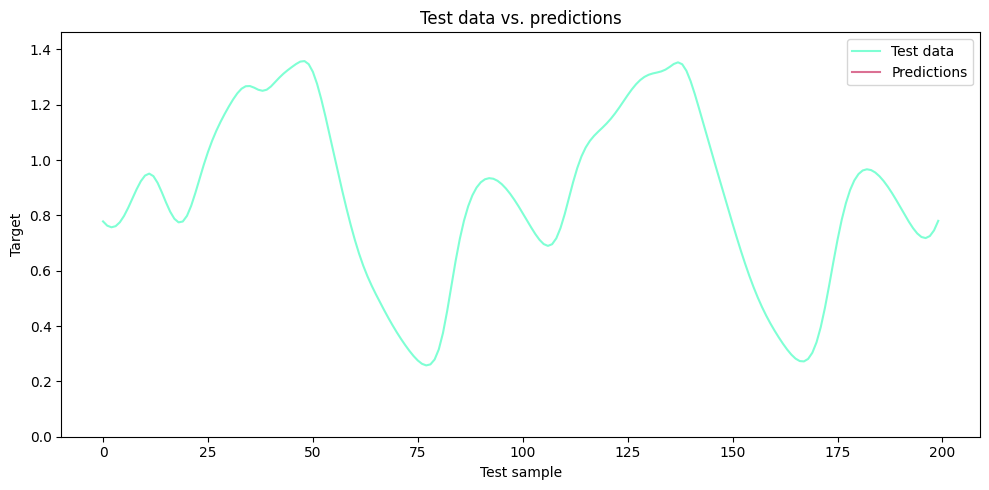

-----------------------
Layer 1:  1     Layer 2:  2
Learning rate:  0.0     L2 weight decay:  0.0
Best validation MSE:  1.372450351715088
Test MSE:  1.269527792930603


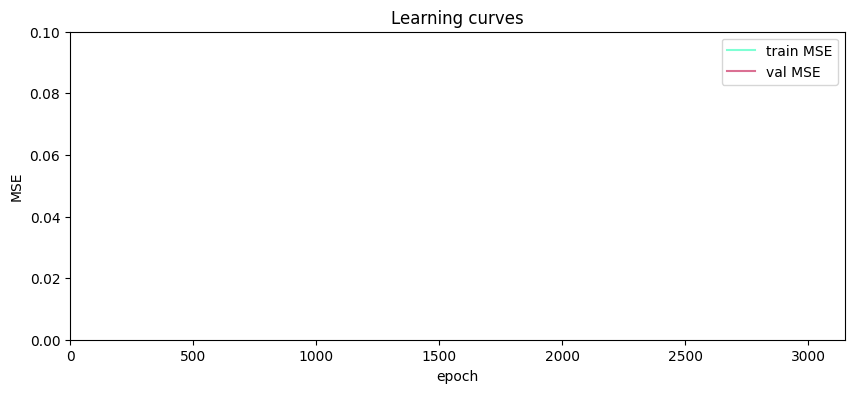

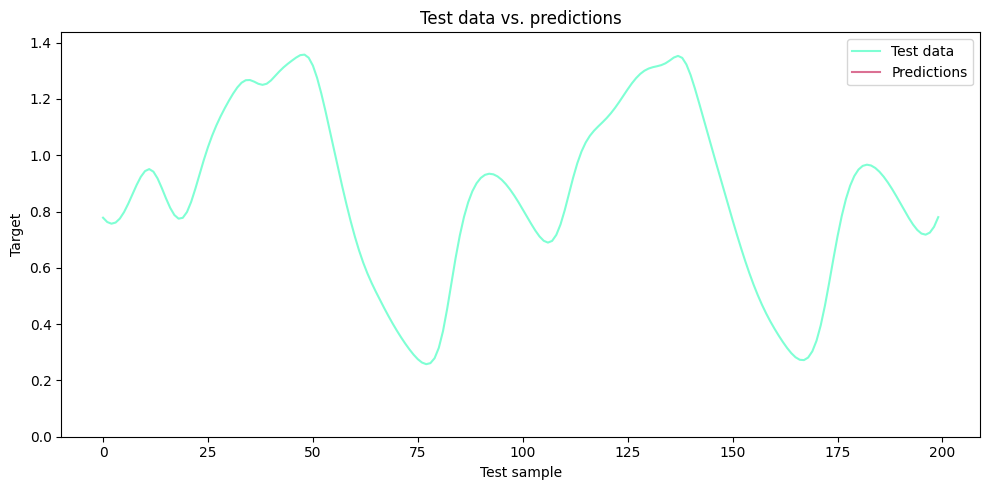

Mean MSE: 1.281102
Std MSE:  0.917892


In [32]:
n_runs = 8
results = []

for i in range(n_runs):
    test_mse = evaluate(
                hidden_size_1=1,
                hidden_size_2=2,
                lr=0.0,
                lambdaL2=0.000,
                earlyStopping=3000,
                epochs=3000,
                info=True,
                test_plot = True
            )

    results.append(test_mse)

results = np.array(results)

print(f"Mean MSE: {results.mean():.6f}")
print(f"Std MSE:  {results.std():.6f}")

In [33]:
X_train_copy = X_train.clone()

-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.0
Best validation MSE:  0.001767361187376082
Test MSE:  0.0013255482772365212


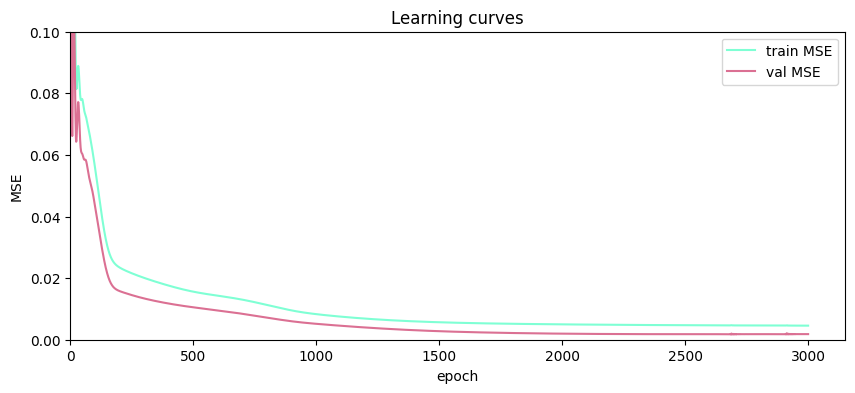

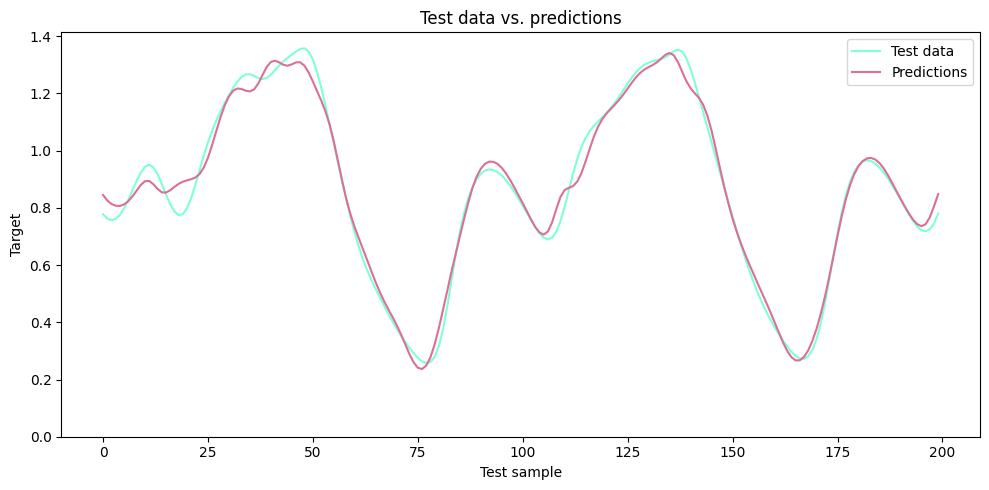

-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.0
Best validation MSE:  0.001690984470769763
Test MSE:  0.0013496789615601301


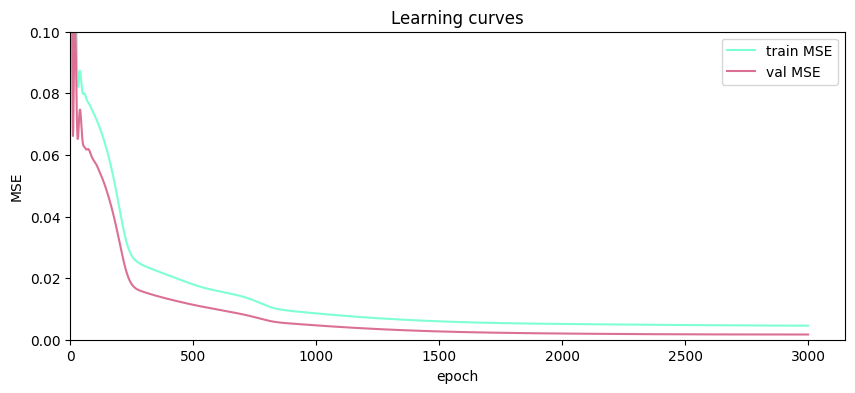

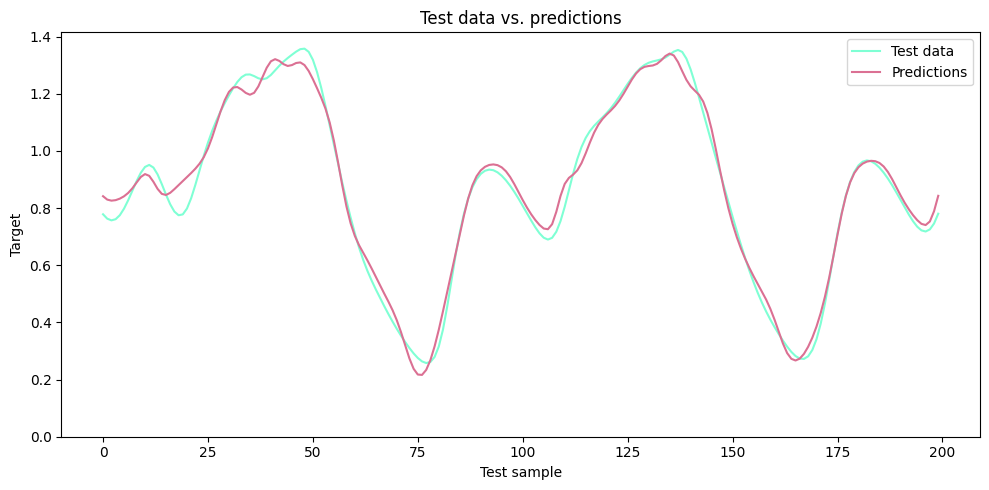

-----------------------
Early stoppng at epoch:  2693
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.0
Best validation MSE:  0.001567909144796431
Test MSE:  0.0012107997899875045


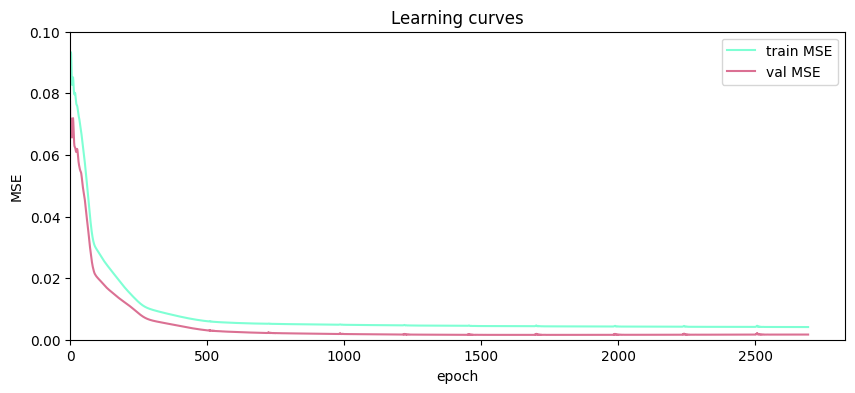

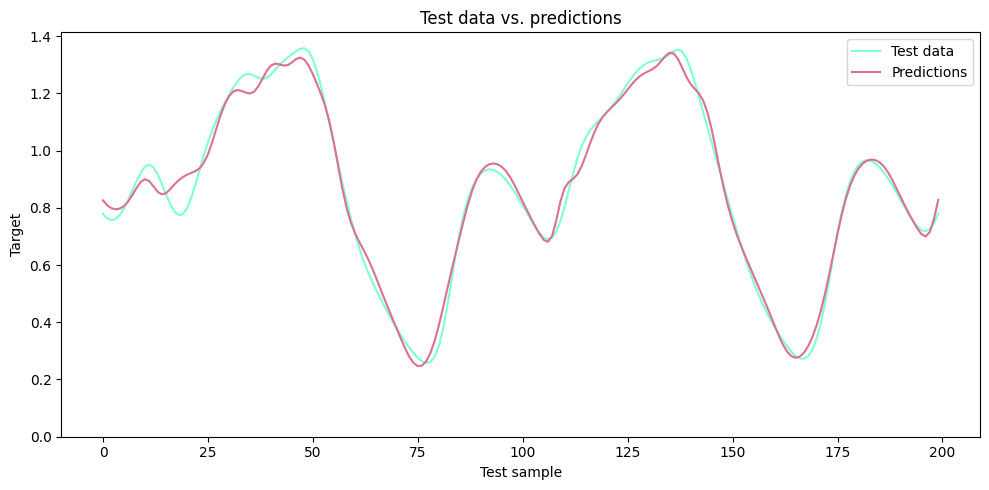

sigma=0.05, nh2=8, lambda=0.0: 0.001675 +/- 0.000082
-----------------------
Early stoppng at epoch:  2591
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.1
Best validation MSE:  0.0032432989683002234
Test MSE:  0.0034154236782342196


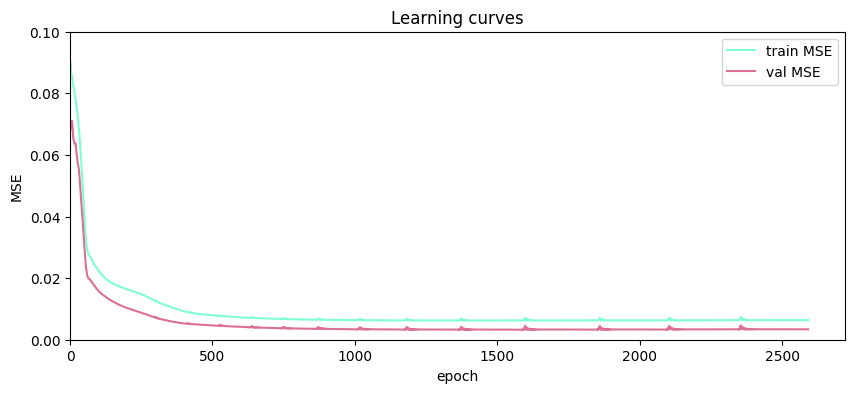

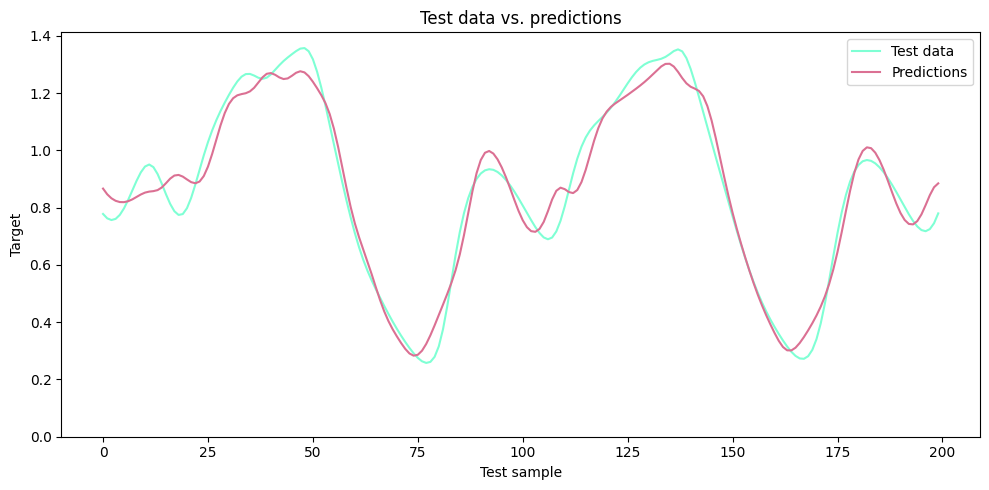

-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.1
Best validation MSE:  0.0028291919734328985
Test MSE:  0.0032669208012521267


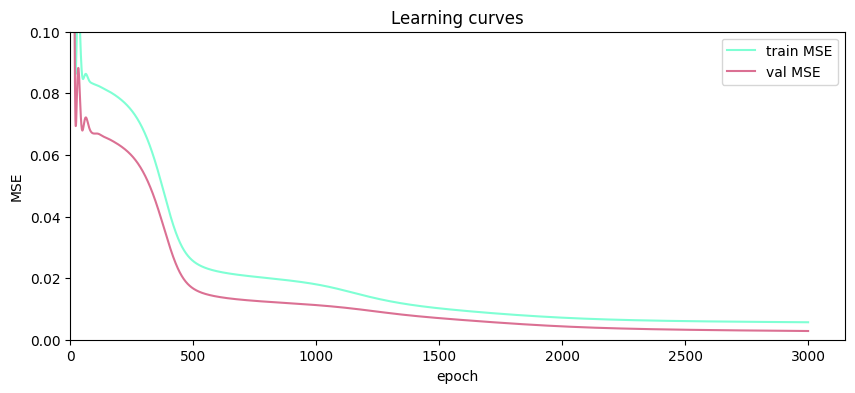

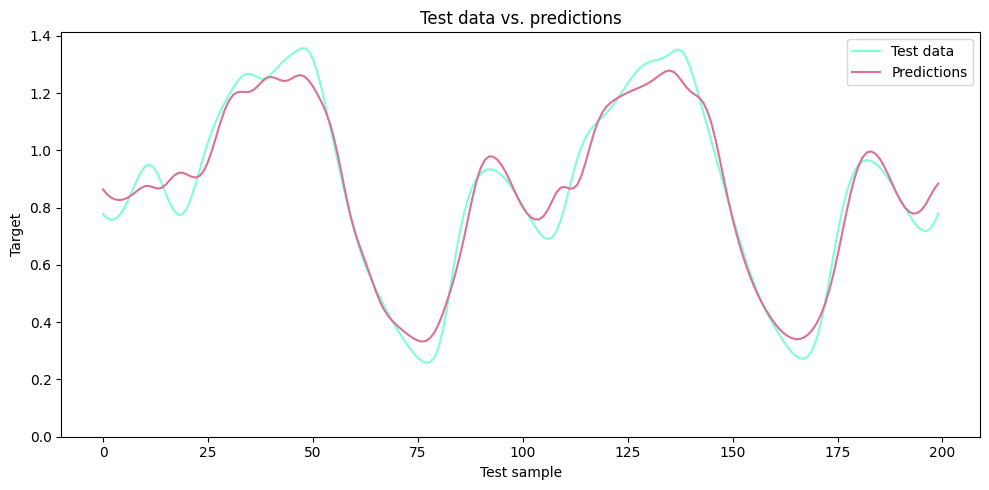

-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.1
Best validation MSE:  0.002974294126033783
Test MSE:  0.003185021923854947


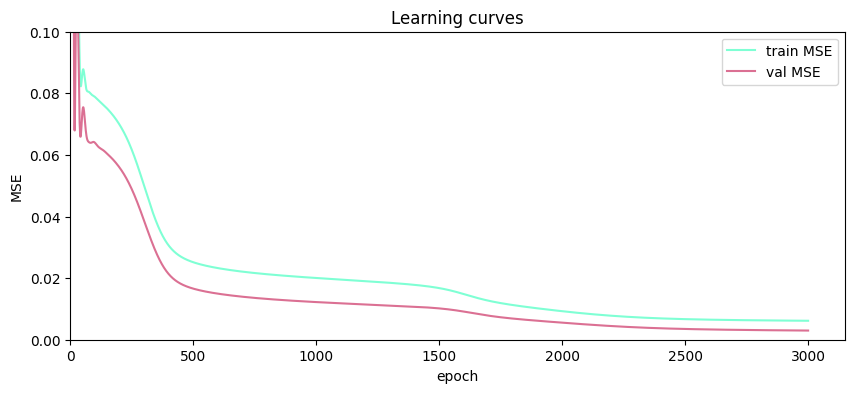

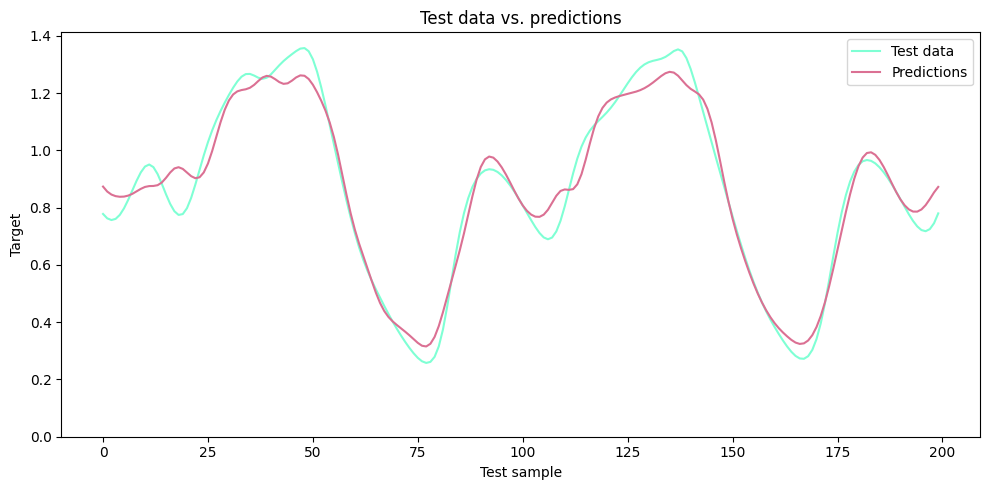

sigma=0.05, nh2=8, lambda=0.1: 0.003016 +/- 0.000172
-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.0
Best validation MSE:  0.007197806611657143
Test MSE:  0.00735716987401247


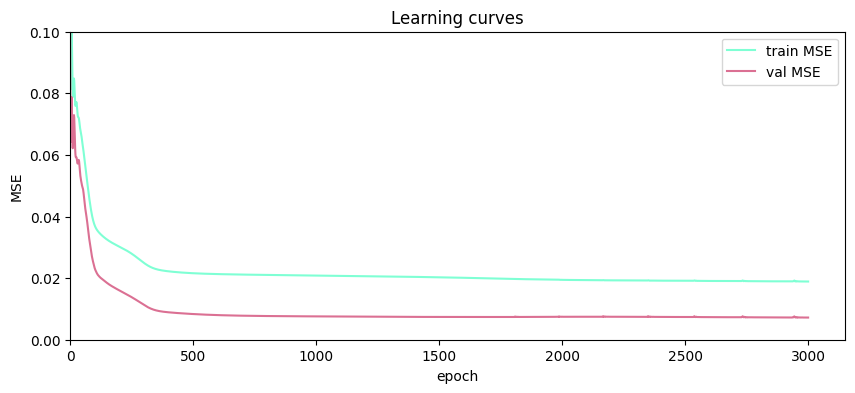

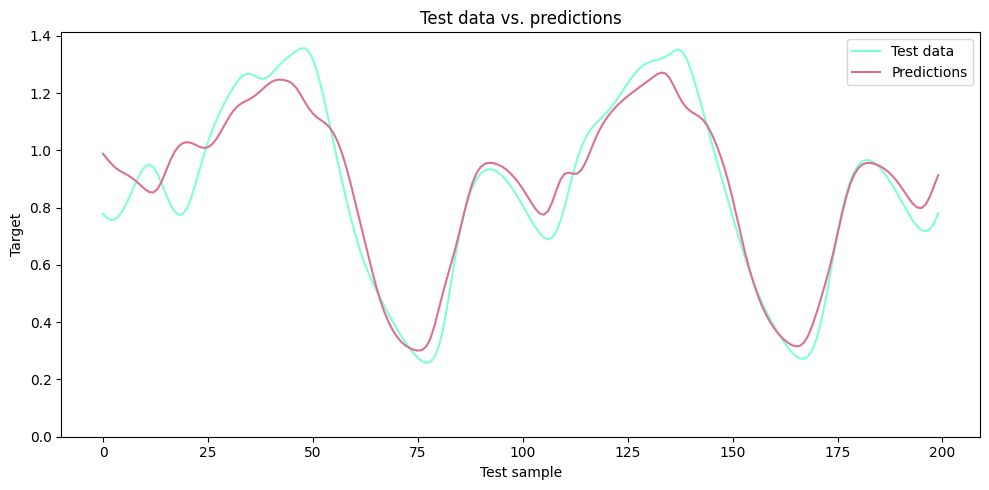

-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.0
Best validation MSE:  0.007194494362920523
Test MSE:  0.00776228541508317


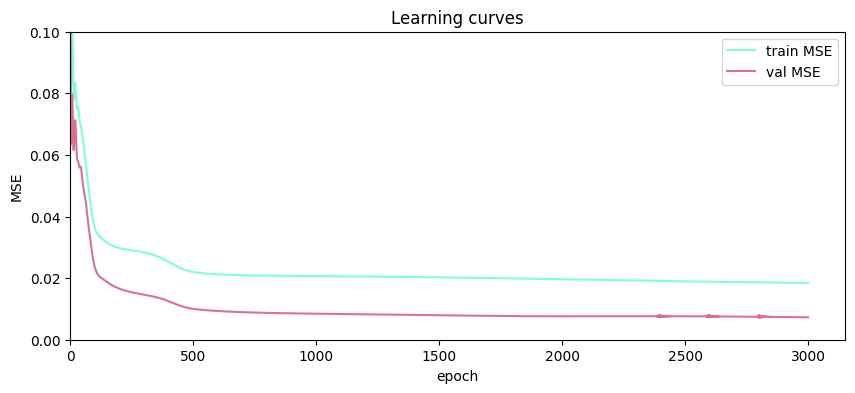

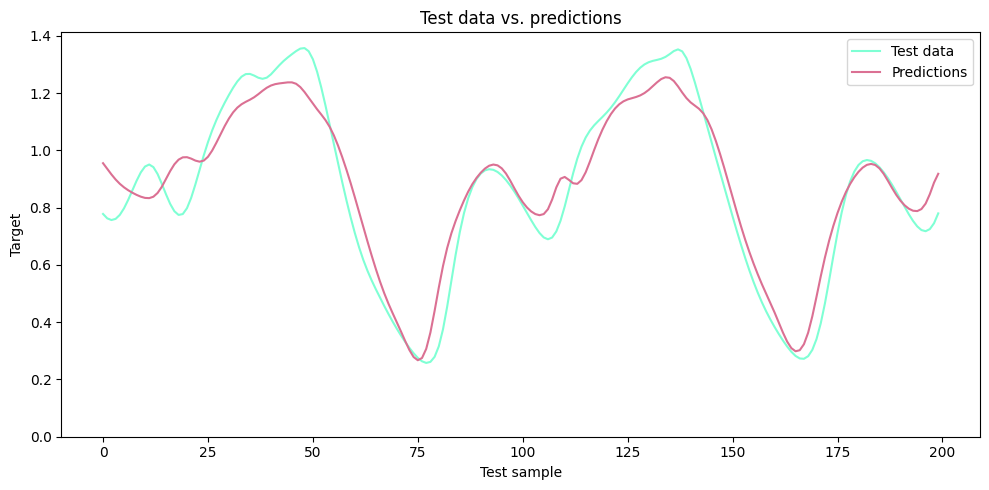

-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.0
Best validation MSE:  0.008289674296975136
Test MSE:  0.010892514139413834


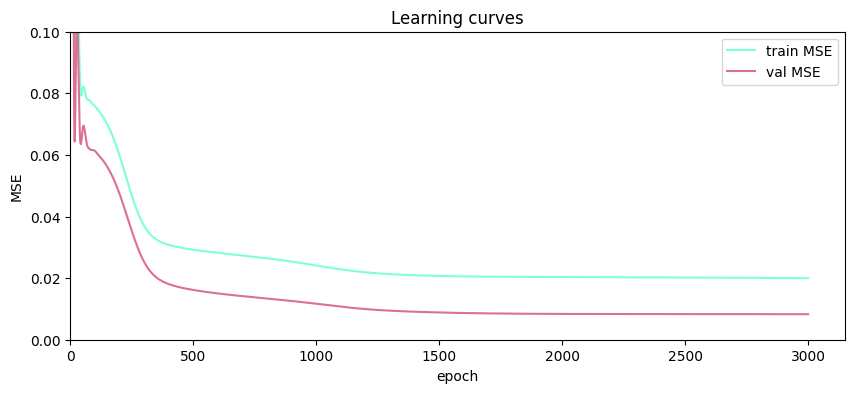

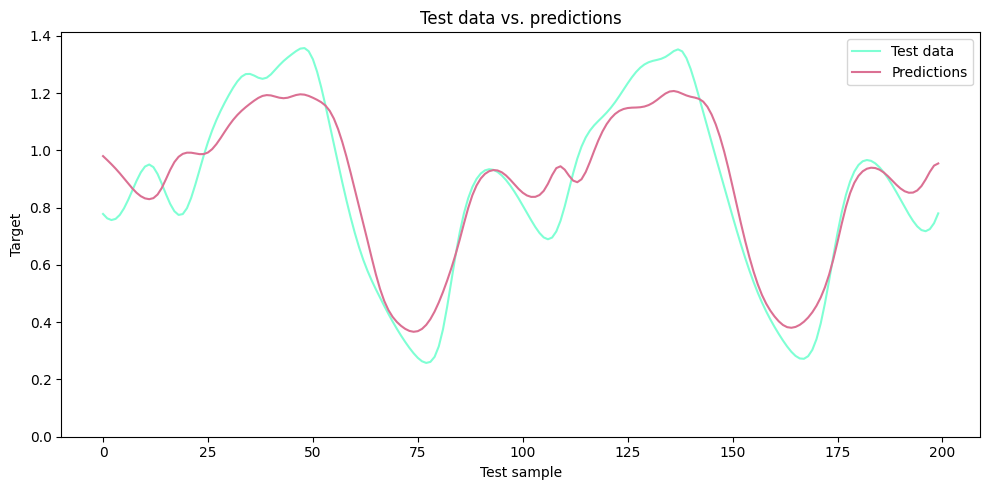

sigma=0.15, nh2=8, lambda=0.0: 0.007561 +/- 0.000515
-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.1
Best validation MSE:  0.008790509775280952
Test MSE:  0.008822554722428322


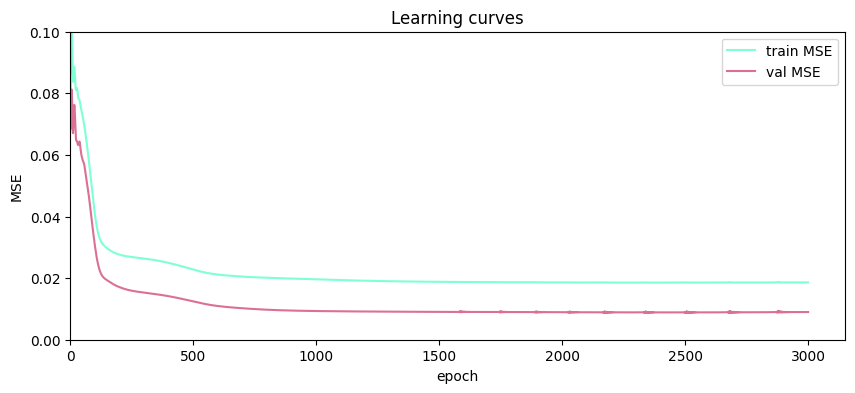

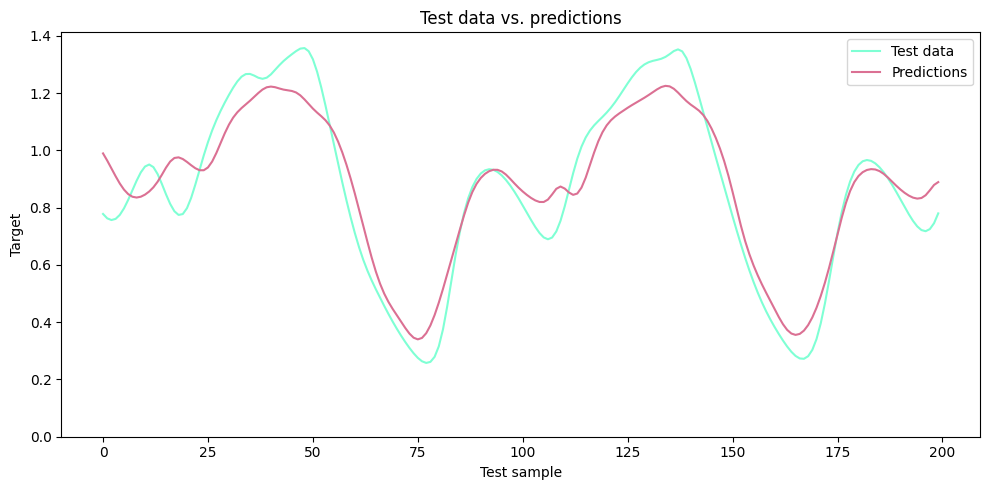

-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.1
Best validation MSE:  0.009528295136988163
Test MSE:  0.012839959003031254


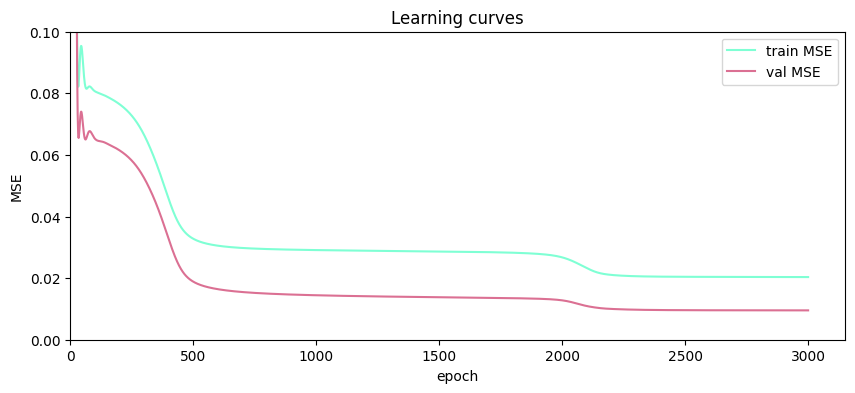

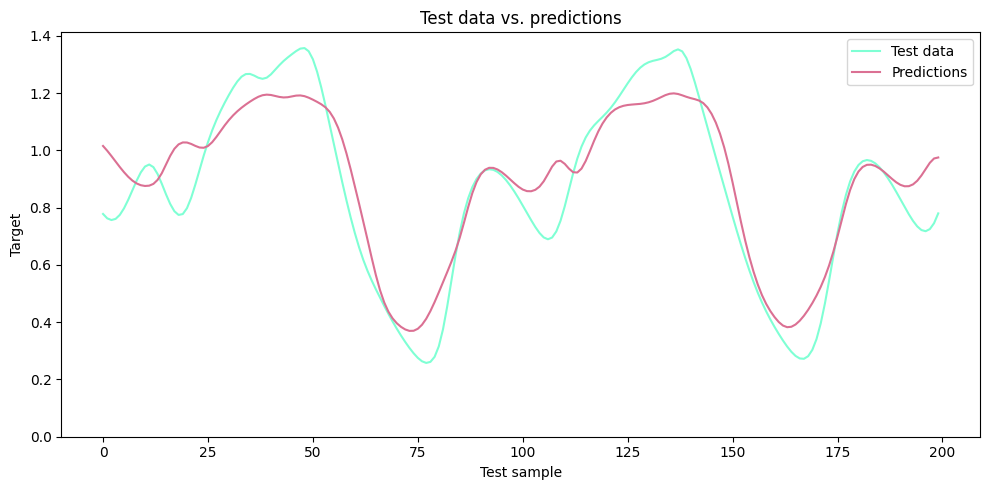

-----------------------
Layer 1:  8     Layer 2:  8
Learning rate:  0.01     L2 weight decay:  0.1
Best validation MSE:  0.007756941020488739
Test MSE:  0.010684411972761154


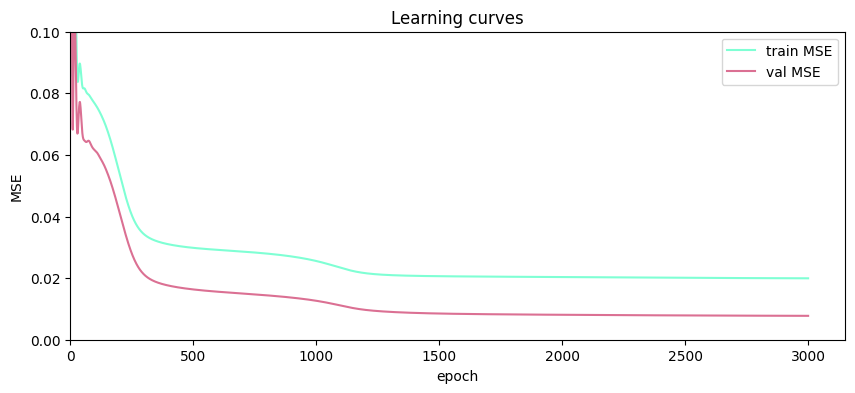

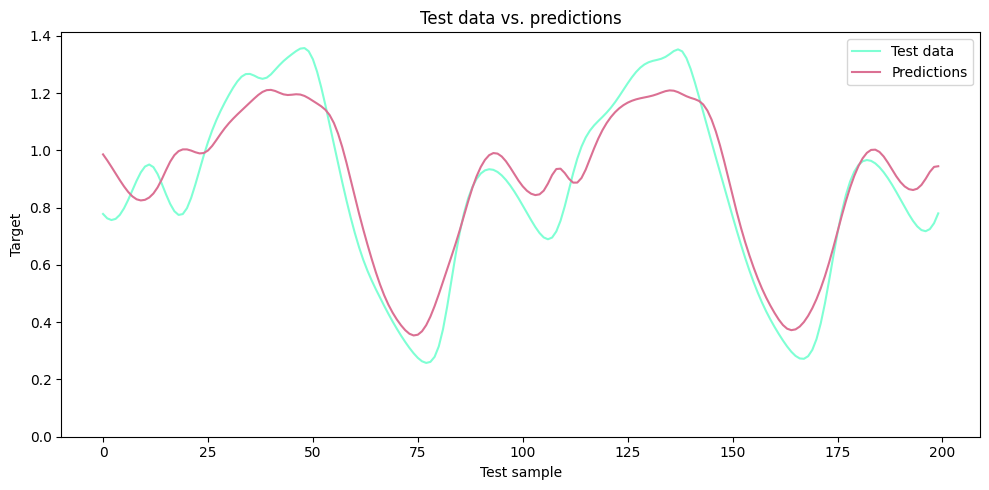

sigma=0.15, nh2=8, lambda=0.1: 0.008692 +/- 0.000727


In [34]:
# Parameters to investigate
sigmas = [0.05, 0.15]
nh2_values = [8]
lambdas = [0.0, 0.1]

n_runs = 3

# Store results:
# results[sigma][nh2][lambda] = list of MSEs
all_results = {}

for sigma in sigmas:

    all_results[sigma] = {}

    for nh2 in nh2_values:

        all_results[sigma][nh2] = {}

        for lambdaL2 in lambdas:

            run_results = []

            for run in range(n_runs):

                # Add fresh Gaussian noise for every run
                X_train = (
                    X_train_copy
                    + sigma * torch.randn_like(X_train_copy)
                )

                mse = evaluate(
                    hidden_size_1=8,
                    hidden_size_2=nh2,
                    lr=0.01,
                    lambdaL2=lambdaL2,
                    earlyStopping=1000,
                    epochs=3000,
                    info=True,
                    test_plot=True
                )

                run_results.append(mse)

            all_results[sigma][nh2][lambdaL2] = run_results

            print(
                f"sigma={sigma}, "
                f"nh2={nh2}, "
                f"lambda={lambdaL2}: "
                f"{np.mean(run_results):.6f} "
                f"+/- {np.std(run_results):.6f}"
            )


